# Notebook 02a — Limpieza de users.csv

**Tabla:** `data/data_raw/users.csv`  
**Objetivo:** Aplicar filtros de calidad, filtro del spike de usuarios abandonados,
definir targets preliminares de churn e investigar el estado de nulos sin imputar.  
**Iteración:** 3 — filtros de engagement relajados (lifespan=0, logins=2), sin muestreo.

## Dependencias

```
pip install pandas numpy pyarrow matplotlib
```

## Outputs esperados

| Archivo | Descripción |
|---|---|
| `data/data_qc/users_clean.parquet` | Dataset filtrado (~127.000 usuarios) |
| `data/data_qc/sample_user_ids.parquet` | IDs de la muestra (= todos, sin muestreo) |
| `data/data_qc/users_post_quality.parquet` | Backup tras filtros básicos |
| `informes/fase1_cleaning/users/execution_report.md` | Informe completo |
| `informes/fase1_cleaning/users/nulos_por_columna.csv` | Nulos iniciales |
| `informes/fase1_cleaning/users/nulos_dataset_final.csv` | Nulos post-filtros |
| `informes/fase1_cleaning/users/spike_investigation.png` | Gráficos del spike |
| `informes/fase1_cleaning/users/engagement_distributions.png` | Distribuciones de features |
| `informes/fase1_cleaning/users/tutorial_dropout_stats.txt` | Stats tutorial |
| `informes/fase1_cleaning/users/sample_head.csv` | Muestra 20 filas |


In [1]:
# [SETUP] Imports y dependencias opcionales

import pandas as pd
import numpy as np
import time
import gc
from pathlib import Path
from datetime import datetime
import matplotlib.ticker as mticker

# Dependencias opcionales con fallback
try:
    import pyarrow
    HAS_PYARROW = True
    print(f"pyarrow {pyarrow.__version__}")
except ImportError:
    HAS_PYARROW = False
    print("pyarrow NO instalado — fallback a CSV")

try:
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
    print("matplotlib disponible")
except ImportError:
    HAS_MATPLOTLIB = False
    print("matplotlib NO instalado")

pyarrow 23.0.1
matplotlib disponible


In [2]:
# [SETUP] Paths, constantes configurables y funciones helper

ROOT      = Path.cwd().parent.parent
DATA_RAW  = ROOT / "data" / "data_raw"
DATA_QC   = ROOT / "data" / "data_qc"
DATA_PROC = ROOT / "data" / "data_processed"
INFORMES  = ROOT / "informes" / "fase1_cleaning" / "users"

for d in [DATA_QC, DATA_PROC, INFORMES]:
    d.mkdir(parents=True, exist_ok=True)

# ============================================================
# FILTROS CONFIGURABLES — cambiar aqui y re-ejecutar el notebook
# ============================================================
#
# Todos los umbrales estan centralizados aqui. Cambia un valor y
# re-ejecuta todas las celdas a partir de la de filtros.

# ── Filtros de calidad basicos ───────────────────────────────
MIN_NUM_LOGINS_BASIC = 5       # Minimo de logins para considerar al usuario
                               # config #1 del grid_search
                               # Alternativas:
                               #   1  = conservar sesiones unicas (ruido)
                               #   2  = default, elimina logins accidentales
                               #   5  = grid_search recomendación
                               #   10 = muy estricto

MIN_YEAR_CREATED     = 2018    # Descartar cuentas creadas antes de este anio
                               # Alternativas:
                               #   2018 = default, el juego no existia antes
                               #   2020 = solo datos modernos
                               #   2022 = muy estricto

# ── Filtro del spike de usuarios abandonados ─────────────────
SPIKE_MAX_DAYS = 7             # Maximo de dias desde el ultimo login permitido
                               # config #1 del grid_search: solo usuarios MUY activos al cutoff
                               # Alternativas:
                               #   365 = muy permisivo
                               #   180 = 6 meses
                               #   120 = 4 meses
                               #    90 = default, estandar MAU
                               #    60 = estricto
                               #    30 = extremo
                               #     7 = grid_search recomendación (balance_score=0.94)

# ── Filtros de engagement — RELAJADOS en esta iteracion ──────
# Mantenemos el filtro del spike pero eliminamos los de engagement
# para no perder casos de interes (early-churn, baja intensidad).
MIN_LIFESPAN_DAYS = 0          # Sin filtro de lifespan
                               # Alternativas:
                               #    0  = default, sin filtro (todos los casos)
                               #    3  = conservador
                               #    7  = estricto (iteracion anterior)
                               #   14  = muy estricto

MIN_NUM_LOGINS_ENGAGEMENT = 2  # Relajado al minimo
                               # Alternativas:
                               #    2  = default, solapa con filtro basico
                               #    3  = iteracion anterior
                               #    5  = estricto
                               #   10  = muy estricto

# ── Muestra ──────────────────────────────────────────────────
SAMPLE_SIZE = None             # Sin muestreo, usar dataset completo
                               # Alternativas:
                               #    None    = default, todos los usuarios
                               #    50_000  = iteracion rapida
                               #   100_000  = muestra estandar
                               #   200_000  = muestra grande

RANDOM_SEED = 42               # Semilla para reproducibilidad

# ── Cutoff temporal (separación features ↔ target) ───────────
# Ver discusión en informes/fase3_modeling/03b_lightgbm_no_recency/
# CUTOFF_DATE = REFERENCE_DATE - 30d. Se calcula tras conocer REFERENCE_DATE.
CUTOFF_OFFSET_DAYS = 120       # Días antes de REFERENCE_DATE para el cutoff (config #1 del grid_search)
TARGET_WINDOWS_DAYS = [14, 30] # Ventanas post-cutoff para los targets
SPIKE_MAX_DAYS_AT_CUTOFF = 90  # Spike: actividad ≤ 90d antes del cutoff

# ============================================================
# NOTA: si cambias alguna constante, re-ejecuta desde la celda
# de filtros de calidad en adelante.
# ============================================================

CHURN_WINDOWS_DAYS = [14, 30]

np.random.seed(RANDOM_SEED)
pd.set_option('display.max_columns', None)

def save_df(df, path, desc=""):
    if HAS_PYARROW:
        out = path.with_suffix('.parquet')
        df.to_parquet(out, index=False)
    else:
        out = path.with_suffix('.csv')
        df.to_csv(out, index=False)
    size_mb = out.stat().st_size / 1_048_576
    suffix = f' — {desc}' if desc else ''
    print(f"  {out.name} — {len(df):,} filas × {len(df.columns)} cols ({size_mb:.1f} MB){suffix}")
    return out

NOTEBOOK_START = time.time()

print(f"ROOT         : {ROOT}")
print(f"DATA_QC      : {DATA_QC}")
print(f"INFORMES     : {INFORMES}")
print()
print("Constantes cargadas:")
print(f"  SPIKE_MAX_DAYS            = {SPIKE_MAX_DAYS}")
print(f"  MIN_LIFESPAN_DAYS         = {MIN_LIFESPAN_DAYS}")
print(f"  MIN_NUM_LOGINS_ENGAGEMENT = {MIN_NUM_LOGINS_ENGAGEMENT}")
print(f"  SAMPLE_SIZE               = {SAMPLE_SIZE}")

ROOT         : /Users/jezquerro/Documents/tfg
DATA_QC      : /Users/jezquerro/Documents/tfg/data/data_qc
INFORMES     : /Users/jezquerro/Documents/tfg/informes/fase1_cleaning/users

Constantes cargadas:
  SPIKE_MAX_DAYS            = 7
  MIN_LIFESPAN_DAYS         = 0
  MIN_NUM_LOGINS_ENGAGEMENT = 2
  SAMPLE_SIZE               = None


In [3]:
# [SETUP] execution_log y helpers de logging

execution_log = []

def log_step(tag, description, extra=""):
    execution_log.append({
        'tag': tag,
        'description': description,
        'extra': extra,
        'timestamp': datetime.now().strftime('%H:%M:%S')
    })

print("execution_log inicializado")

execution_log inicializado


In [4]:
# [EXEC] Cargar users.csv, extraer user_id desde ObjectId y parsear fechas

import re

t0 = time.time()
csv_path = DATA_RAW / "users.csv"
print(f"Cargando {csv_path} ...")

users = pd.read_csv(csv_path, low_memory=False)
t_load = time.time() - t0
print(f"  Cargado en {t_load:.1f}s — shape: {users.shape}")

# Extraer user_id desde ObjectId('...')
_id_col = '_id' if '_id' in users.columns else users.columns[0]
users['user_id'] = (
    users[_id_col].astype(str)
    .str.extract(r"ObjectId\(?'?([a-f0-9]+)'?\)?", expand=False)
    .fillna(users[_id_col].astype(str))
)
n_valid_ids = users['user_id'].notna().sum()
print(f"  user_ids validos: {n_valid_ids:,}/{len(users):,}")
# Validar que user_id es hex limpio de 24 caracteres
sample_uid = users['user_id'].dropna().iloc[0]
assert len(sample_uid) == 24 and not sample_uid.startswith('ObjectId'), \
    f"ERROR: user_id no es hex limpio. Ejemplo: '{sample_uid}'. Revisar la regex de extracción."
print(f"  Formato user_id OK: '{sample_uid}' (len={len(sample_uid)})")

# Parsear created_at_dt
if 'created_at' in users.columns:
    users['created_at_dt'] = pd.to_datetime(users['created_at'], errors='coerce', utc=True)
    users['created_at_dt'] = users['created_at_dt'].dt.tz_localize(None)
elif 'created_at_dt' not in users.columns:
    users['created_at_dt'] = pd.NaT

# Parsear last_login_dt
if 'last_login_date' in users.columns:
    users['last_login_dt'] = pd.to_datetime(users['last_login_date'], unit='s', errors='coerce')
elif 'last_login_dt' not in users.columns:
    users['last_login_dt'] = pd.NaT

print(f"  created_at_dt nulos: {users['created_at_dt'].isna().sum():,}")
print(f"  last_login_dt nulos: {users['last_login_dt'].isna().sum():,}")

log_step("EXEC", "Carga de users.csv",
         f"shape={users.shape}, tiempo={t_load:.1f}s, user_ids validos={n_valid_ids:,}/{len(users):,}")

Cargando /Users/jezquerro/Documents/tfg/data/data_raw/users.csv ...


  Cargado en 4.1s — shape: (1164568, 30)


  user_ids validos: 1,164,568/1,164,568
  Formato user_id OK: '5eaa8f81fcdbdc3878446480' (len=24)


  created_at_dt nulos: 0
  last_login_dt nulos: 270


In [5]:
# [ANALYSIS] Exploración inicial: shape, dtypes, head, % nulos

print(f"Shape: {users.shape}")
print(f"Columnas ({len(users.columns)}):")
print(users.dtypes.to_string())
print()

# Nulos por columna
nulos = users.isna().sum().sort_values(ascending=False)
nulos_pct = (nulos / len(users) * 100).round(2)
nulos_df = pd.DataFrame({'n_null': nulos, 'pct_null': nulos_pct})
nulos_df = nulos_df[nulos_df['n_null'] > 0]
print("Columnas con nulos:")
print(nulos_df.to_string())

# Guardar
nulos_all = pd.DataFrame({
    'columna': users.columns,
    'dtype': users.dtypes.values,
    'n_null': users.isna().sum().values,
    'pct_null': (users.isna().sum() / len(users) * 100).round(2).values,
})
nulos_csv = INFORMES / "nulos_por_columna.csv"
nulos_all.to_csv(nulos_csv, index=False)
print(f"\nGuardado: {nulos_csv}")

log_step("ANALYSIS", "Exploración inicial", "guardado nulos_por_columna.csv")

Shape: (1164568, 33)
Columnas (33):
_id                                                   str
own_id                                            float64
last_login_date                                   float64
num_logins                                        float64
total_time_played                                 float64
session_mean_time                                 float64
game_version                                      float64
tutorial_done                                      object
last_completed_tutorial_block                     float64
show_arena_announcer                               object
show_new_arena_announcer                           object
show_village_announcer                             object
show_talents_announcer                             object
show_quests_announcer                              object
show_tower_event_announcer                         object
current_session                                       str
country                             

Columnas con nulos:
                                         n_null  pct_null
template_item_stats_augment_update_done  511654     43.94
runes                                    511654     43.94
current_character                        253182     21.74
dark_steel                               252077     21.65
gems                                     252077     21.65
gold                                     252077     21.65
store_where_published                    235502     20.22
show_tower_event_announcer               174240     14.96
show_quests_announcer                    159343     13.68
is_google_play                            91322      7.84
country                                   10754      0.92
focus                                     10754      0.92
language                                   6076      0.52
has_user_rated_app                          280      0.02
current_session                             271      0.02
own_id                                      270     


Guardado: /Users/jezquerro/Documents/tfg/informes/fase1_cleaning/users/nulos_por_columna.csv


In [6]:
# [ANALYSIS] Análisis de nulos de gold, gems, dark_steel, runes por año

currency_cols = [c for c in ['gold', 'gems', 'dark_steel', 'runes'] if c in users.columns]
print(f"Columnas de moneda disponibles: {currency_cols}")

if currency_cols and 'created_at_dt' in users.columns:
    users['_year'] = users['created_at_dt'].dt.year
    grp = users.groupby('_year', dropna=False)
    rows = []
    for year, g in grp:
        row = {'year': year, 'n': len(g)}
        for col in currency_cols:
            pct_nonzero = ((g[col].notna()) & (g[col] != 0)).mean() * 100
            row[f'{col}_pct_nonzero'] = round(pct_nonzero, 1)
        rows.append(row)
    tbl = pd.DataFrame(rows)
    print("\n% de valores no-cero por año:")
    print(tbl.to_string(index=False))
    users.drop(columns=['_year'], inplace=True)

log_step("ANALYSIS", "Análisis nulos gold/gems/dark_steel/runes por año",
         f"columnas: {currency_cols}")

Columnas de moneda disponibles: ['gold', 'gems', 'dark_steel', 'runes']



% de valores no-cero por año:
 year      n  gold_pct_nonzero  gems_pct_nonzero  dark_steel_pct_nonzero  runes_pct_nonzero
 2020   2993               0.1               0.1                     0.1                0.0
 2021   6053               0.2               0.1                     0.1                0.0
 2022 123157               6.1               4.0                     6.0                0.2
 2023 133308              10.7               6.4                    10.6                0.4
 2024 167943              95.1              49.4                    94.5                0.7
 2025 399623             100.0              31.9                    99.8                1.6
 2026 331491             100.0              11.1                    99.9                0.5


In [7]:
# [EXEC] Calcular REFERENCE_DATE y CUTOFF_DATE

REFERENCE_DATE = users['last_login_dt'].max()
CUTOFF_DATE = REFERENCE_DATE - pd.Timedelta(days=CUTOFF_OFFSET_DAYS)

print(f"REFERENCE_DATE = {REFERENCE_DATE}")
print(f"  (máximo de last_login_dt en users.csv)")
print(f"CUTOFF_DATE    = {CUTOFF_DATE}")
print(f"  (= REFERENCE_DATE - {CUTOFF_OFFSET_DAYS}d, separa features ↔ target)")

log_step("EXEC", "REFERENCE_DATE calculado", str(REFERENCE_DATE))
log_step("EXEC", "CUTOFF_DATE calculado", str(CUTOFF_DATE))

REFERENCE_DATE = 2026-04-04 18:23:37
  (máximo de last_login_dt en users.csv)
CUTOFF_DATE    = 2025-12-05 18:23:37
  (= REFERENCE_DATE - 120d, separa features ↔ target)


## Tutorial dropout

Antes de aplicar filtros calculamos la tasa de abandono en el tutorial.
Este dato es relevante para la memoria del TFG: muestra qué porcentaje de
usuarios instala el juego pero nunca completa el onboarding.

Tutorial dropout:
  Total usuarios    : 1,164,568
  Tutorial completo : 878,648 (75.4%)
  Tutorial NO hecho : 285,920 (24.6%)

Distribución por último bloque (usuarios que NO completaron):
last_completed_tutorial_block
-1.0    192815
 2.0     24445
 0.0     18626
 1.0     16567
 4.0     15844
 3.0     12701
 6.0      3431
 5.0      1216
 NaN       270
 7.0         5

Guardado: /Users/jezquerro/Documents/tfg/informes/fase1_cleaning/users/tutorial_dropout_stats.txt


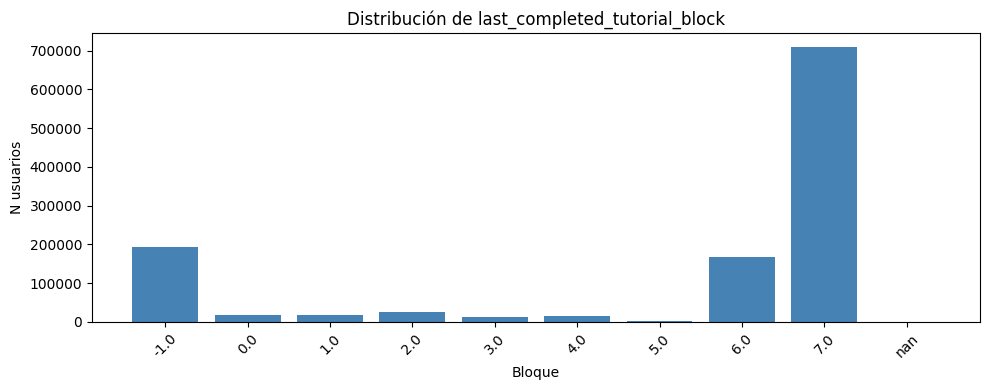

Gráfico guardado: /Users/jezquerro/Documents/tfg/informes/fase1_cleaning/users/tutorial_dropout.png


In [8]:
# [ANALYSIS] Tutorial dropout: porcentajes, distribución por bloque

if 'tutorial_done' in users.columns:
    n_total = len(users)
    n_done = (users['tutorial_done'] == True).sum()
    n_not_done = n_total - n_done
    pct_not_done = n_not_done / n_total * 100

    print(f"Tutorial dropout:")
    print(f"  Total usuarios    : {n_total:,}")
    print(f"  Tutorial completo : {n_done:,} ({n_done/n_total*100:.1f}%)")
    print(f"  Tutorial NO hecho : {n_not_done:,} ({pct_not_done:.1f}%)")

    # Distribución por bloque
    if 'last_completed_tutorial_block' in users.columns:
        dropout_only = users[users['tutorial_done'] != True]
        block_dist = dropout_only['last_completed_tutorial_block'].value_counts(dropna=False).head(15)
        print(f"\nDistribución por último bloque (usuarios que NO completaron):")
        print(block_dist.to_string())

    # Guardar stats
    stats_path = INFORMES / "tutorial_dropout_stats.txt"
    with open(stats_path, 'w') as f:
        f.write(f"Tutorial dropout stats\n")
        f.write(f"Generado: {datetime.now()}\n\n")
        f.write(f"Total usuarios    : {n_total:,}\n")
        f.write(f"Tutorial completo : {n_done:,} ({n_done/n_total*100:.1f}%)\n")
        f.write(f"Tutorial NO hecho : {n_not_done:,} ({pct_not_done:.1f}%)\n")
    print(f"\nGuardado: {stats_path}")

    # Gráfico
    if HAS_MATPLOTLIB and 'last_completed_tutorial_block' in users.columns:
        fig, ax = plt.subplots(figsize=(10, 4))
        vc = users['last_completed_tutorial_block'].value_counts(dropna=False).sort_index()
        ax.bar(range(len(vc)), vc.values, color='steelblue')
        ax.set_xticks(range(len(vc)))
        ax.set_xticklabels([str(x) for x in vc.index], rotation=45)
        ax.set_title('Distribución de last_completed_tutorial_block')
        ax.set_xlabel('Bloque')
        ax.set_ylabel('N usuarios')
        plt.tight_layout()
        plot_path = INFORMES / "tutorial_dropout.png"
        plt.savefig(plot_path, dpi=100, bbox_inches='tight')
        plt.show()
        print(f"Gráfico guardado: {plot_path}")

    log_step("ANALYSIS", "Tutorial dropout",
             f"{pct_not_done:.1f}% de usuarios ({n_not_done:,}) no completan el tutorial")
else:
    print("AVISO: columna 'tutorial_done' no encontrada")
    log_step("ANALYSIS", "Tutorial dropout", "columna no encontrada")

In [9]:
# [EXEC] Filtros de calidad básicos con desglose individual

filter_steps = []

def apply_filter(df, mask, step_name):
    n_before = len(df)
    df_out = df[mask].copy()
    n_after = len(df_out)
    delta = n_after - n_before
    pct_elim = abs(delta) / n_before * 100 if n_before > 0 else 0
    filter_steps.append({
        'step': step_name,
        'n_before': n_before,
        'n_after': n_after,
        'delta': delta,
        'pct_elim': pct_elim,
    })
    return df_out

users_clean = users.copy()

# F1: tutorial completado
if 'tutorial_done' in users_clean.columns:
    users_clean = apply_filter(users_clean,
                               users_clean['tutorial_done'] == True,
                               'F1: tutorial_done == True')

# F2: last_login_date válida
if 'last_login_dt' in users_clean.columns:
    users_clean = apply_filter(users_clean,
                               users_clean['last_login_dt'].notna() &
                               (users_clean['last_login_dt'].dt.year > 2018),
                               'F2: last_login_date > 2018')

# F3: num_logins mínimo
if 'num_logins' in users_clean.columns:
    users_clean = apply_filter(users_clean,
                               users_clean['num_logins'] >= MIN_NUM_LOGINS_BASIC,
                               f'F3: num_logins >= {MIN_NUM_LOGINS_BASIC}')

# F4: año de creación mínimo
if 'created_at_dt' in users_clean.columns:
    users_clean = apply_filter(users_clean,
                               users_clean['created_at_dt'].dt.year >= MIN_YEAR_CREATED,
                               f'F4: created_at year >= {MIN_YEAR_CREATED}')

# F5: cutoff temporal — el jugador debe existir al cutoff
if 'created_at_dt' in users_clean.columns:
    users_clean = apply_filter(users_clean,
                               users_clean['created_at_dt'] <= CUTOFF_DATE,
                               f'F5: created_at <= CUTOFF ({CUTOFF_DATE.date()})')

# Imprimir tabla de desglose
n_inicial = len(users)
print("Desglose de filtros de calidad:")
print("-" * 70)
print(f"  {'Paso':<40} {'N filas':>10}  {'Delta':>10}  {'% elim':>8}")
print("-" * 70)
print(f"  {'Inicial':<40} {n_inicial:>10,}")
for s in filter_steps:
    print(f"  {s['step']:<40} {s['n_after']:>10,}  {s['delta']:>10,}  ({s['pct_elim']:.1f}%)")
print("-" * 70)
print(f"\nTotal retenido: {len(users_clean):,} / {n_inicial:,} ({len(users_clean)/n_inicial*100:.1f}%)")

log_step("EXEC", "Filtros de calidad aplicados (desglose)",
         f"{n_inicial:,} -> {len(users_clean):,} filas ({len(users_clean)/n_inicial*100:.1f}% retenido)")

Desglose de filtros de calidad:
----------------------------------------------------------------------
  Paso                                        N filas       Delta    % elim
----------------------------------------------------------------------
  Inicial                                   1,164,568
  F1: tutorial_done == True                   878,648    -285,920  (24.6%)
  F2: last_login_date > 2018                  878,648           0  (0.0%)
  F3: num_logins >= 5                         522,482    -356,166  (40.5%)
  F4: created_at year >= 2018                 522,482           0  (0.0%)
  F5: created_at <= CUTOFF (2025-12-05)       460,032     -62,450  (12.0%)
----------------------------------------------------------------------

Total retenido: 460,032 / 1,164,568 (39.5%)


In [10]:
# [EXEC] Calcular days_since_last_login y player_lifespan_days

# Medido al CUTOFF_DATE (no a REFERENCE_DATE) — separa features de target
users_clean['days_since_last_login'] = (
    (CUTOFF_DATE - users_clean['last_login_dt'])
    .dt.total_seconds() / 86400
).round(0).astype(int).clip(lower=0)  # clip por jugadores activos exactamente en cutoff

# Lifespan: clip last_login al cutoff (no contamos actividad post-cutoff)
last_login_clipped = users_clean['last_login_dt'].clip(upper=CUTOFF_DATE)
users_clean['player_lifespan_days'] = (
    (last_login_clipped - users_clean['created_at_dt'])
    .dt.total_seconds() / 86400
).round(0).astype(int)

# Marcar negativos sin eliminarlos
users_clean['has_corrupted_dates'] = users_clean['player_lifespan_days'] < 0
n_corrupted = users_clean['has_corrupted_dates'].sum()

print(f"days_since_last_login:")
print(f"  min: {users_clean['days_since_last_login'].min()}")
print(f"  max: {users_clean['days_since_last_login'].max()}")
print(f"  mediana: {users_clean['days_since_last_login'].median():.0f}")
print(f"\nplayer_lifespan_days:")
print(f"  mediana: {users_clean['player_lifespan_days'].median():.0f}d")
print(f"  negativos: {n_corrupted:,} marcados con has_corrupted_dates")

log_step("EXEC", "player_lifespan_days calculado",
         f"mediana={users_clean['player_lifespan_days'].median():.0f}d, negativos={n_corrupted} marcados con has_corrupted_dates")

days_since_last_login:
  min: 0
  max: 2045
  mediana: 444

player_lifespan_days:
  mediana: 5d
  negativos: 0 marcados con has_corrupted_dates


In [11]:
# [EXEC] Guardar backup users_post_quality.parquet antes del filtro del spike

save_df(users_clean, DATA_QC / "users_post_quality", "backup post-filtros de calidad")

log_step("EXEC", "Backup post-calidad guardado", f"{len(users_clean):,} filas en users_post_quality")

  users_post_quality.parquet — 460,032 filas × 36 cols (48.0 MB) — backup post-filtros de calidad


## Análisis exploratorio sobre el dataset PRE-FILTRO

Las celdas siguientes (investigación del spike, comparativa de umbrales,
investigación de variables de engagement, comparativa de filtros) operan
sobre el dataset **post-calidad básica** pero **PRE-filtro del spike**
(773,805 usuarios). Son análisis exploratorios para **justificar las
decisiones de filtrado**, no representan el dataset que el modelo usará.

El dataset final (post-filtro spike) se analiza en celdas posteriores
identificadas con "POST-FILTRO".

## Investigación del spike de usuarios abandonados

Al calcular `days_since_last_login` observamos un spike masivo de usuarios
con valores muy altos (>365 días). Estos son cuentas históricas que llevan
más de un año sin conectarse.

En las siguientes celdas caracterizamos este spike y comparamos distintos
umbrales para decidir cuál aplicar.

In [12]:
# [ANALYSIS] Segmentar usuarios en buckets y caracterizar

bins = [-1, 300, 364, 10000]
labels = ['<=300d', '301-364d', '>=365d']
users_clean['_bucket'] = pd.cut(users_clean['days_since_last_login'],
                                 bins=bins, labels=labels)

print("Distribución por bucket de days_since_last_login:")
print("-" * 65)
for label in labels:
    grp = users_clean[users_clean['_bucket'] == label]
    n = len(grp)
    pct = n / len(users_clean) * 100
    med_logins = grp['num_logins'].median() if 'num_logins' in grp.columns else 'N/A'
    med_life = grp['player_lifespan_days'].median()
    print(f"  {label:<12} N={n:>8,} ({pct:5.1f}%)  "
          f"med_logins={med_logins}  med_lifespan={med_life:.0f}d")

users_clean.drop(columns=['_bucket'], inplace=True)

log_step("ANALYSIS", "Segmentación en buckets de días", "completado")

Distribución por bucket de days_since_last_login:
-----------------------------------------------------------------
  <=300d       N= 164,528 ( 35.8%)  med_logins=11.0  med_lifespan=8d
  301-364d     N=  36,180 (  7.9%)  med_logins=11.0  med_lifespan=4d
  >=365d       N= 259,324 ( 56.4%)  med_logins=11.0  med_lifespan=4d


In [13]:
# [ANALYSIS] Inspección del spike: top last_login_dt repetidos, distribución

spike = users_clean[users_clean['days_since_last_login'] >= 365].copy()
print(f"Usuarios en spike (>= 365d): {len(spike):,} ({len(spike)/len(users_clean)*100:.1f}%)")

if len(spike) > 0:
    # Top fechas repetidas
    top_dates = spike['last_login_dt'].value_counts().head(10)
    print(f"\nTop 10 last_login_dt más repetidos en el spike:")
    print(top_dates.to_string())

    # Distribución de num_logins en el spike
    if 'num_logins' in spike.columns:
        print(f"\nnum_logins en el spike:")
        print(f"  mediana: {spike['num_logins'].median():.0f}")
        print(f"  media  : {spike['num_logins'].mean():.1f}")
        print(f"  p99    : {spike['num_logins'].quantile(0.99):.0f}")
        print(f"  max    : {spike['num_logins'].max()}")

    # Año de creación del spike
    if 'created_at_dt' in spike.columns:
        year_dist = spike['created_at_dt'].dt.year.value_counts().sort_index()
        print(f"\nAño de creación en el spike:")
        print(year_dist.to_string())

log_step("ANALYSIS", "Investigación del spike",
         f"{len(spike):,} usuarios en >=365d ({len(spike)/len(users_clean)*100:.1f}% del df filtrado)")

Usuarios en spike (>= 365d): 259,324 (56.4%)

Top 10 last_login_dt más repetidos en el spike:
last_login_dt
2022-09-04 09:34:20    6
2022-09-06 18:57:35    6
2022-10-15 18:53:16    6
2023-01-10 16:16:19    6
2023-12-24 17:17:15    6
2022-08-30 07:30:13    5
2023-04-21 18:55:38    5
2023-06-10 16:27:47    5
2023-05-20 19:45:19    5
2024-07-17 17:54:49    5

num_logins en el spike:
  mediana: 11
  media  : 32.0
  p99    : 380
  max    : 14107.0

Año de creación en el spike:
created_at_dt
2020     1825
2021     3318
2022    75449
2023    86592
2024    92140


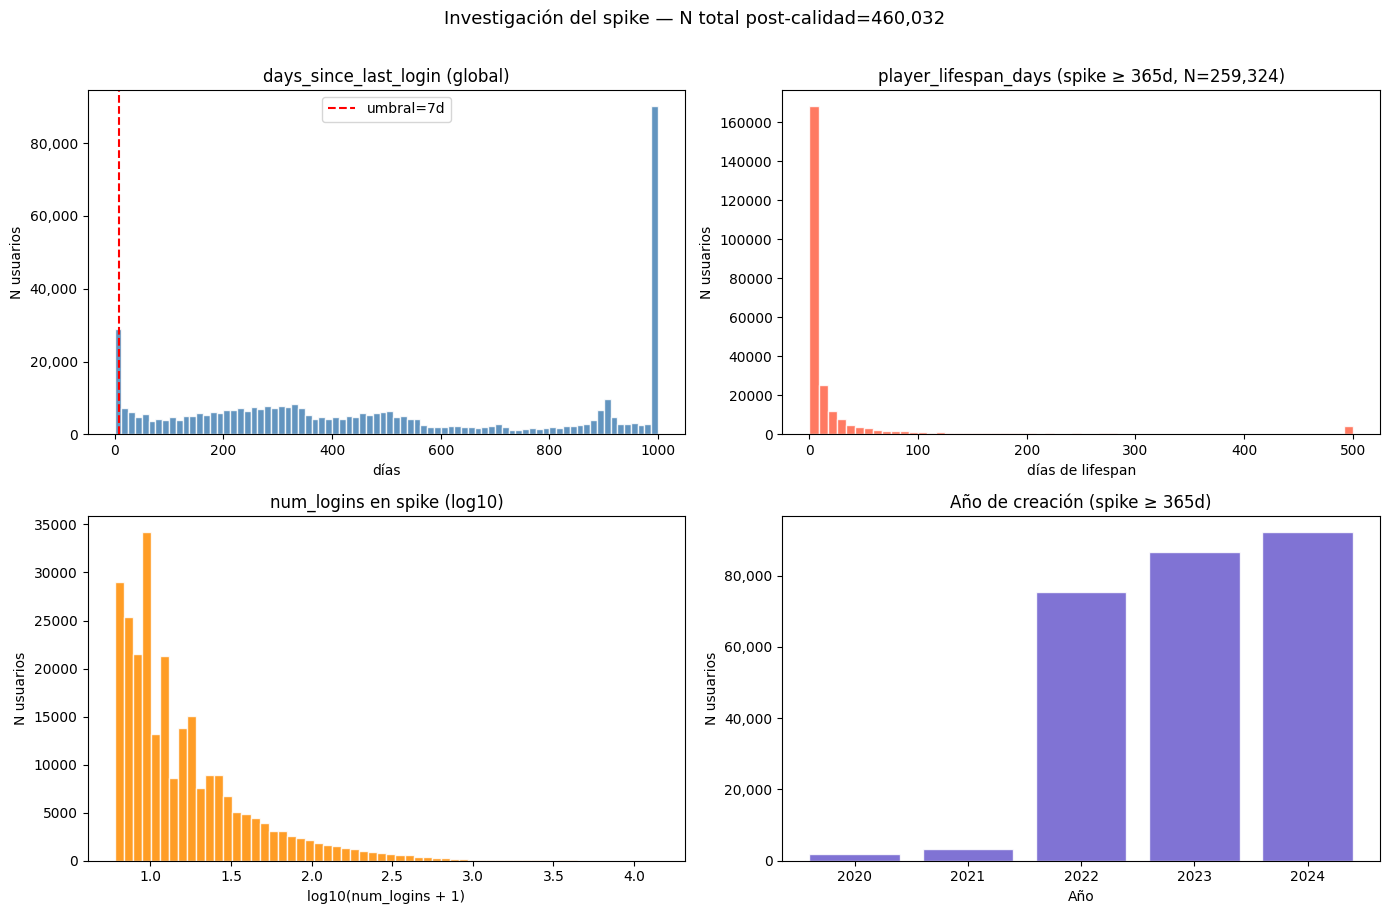

Gráfico guardado: /Users/jezquerro/Documents/tfg/informes/fase1_cleaning/users/spike_investigation.png


In [14]:
# [ANALYSIS] Gráficos del spike: 4 subplots

if HAS_MATPLOTLIB:
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    # 1. Lifespan global
    ax = axes[0, 0]
    data_g = users_clean['days_since_last_login'].clip(0, 1000)
    ax.hist(data_g, bins=80, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(SPIKE_MAX_DAYS, color='red', linestyle='--', label=f'umbral={SPIKE_MAX_DAYS}d')
    ax.set_title('days_since_last_login (global)')
    ax.set_xlabel('días')
    ax.set_ylabel('N usuarios')
    ax.legend()
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

    # 2. Lifespan del spike
    ax = axes[0, 1]
    spike_data = users_clean[users_clean['days_since_last_login'] >= 365]
    ax.hist(spike_data['player_lifespan_days'].clip(-30, 500), bins=60,
            color='tomato', edgecolor='white', alpha=0.85)
    ax.set_title(f'player_lifespan_days (spike ≥ 365d, N={len(spike_data):,})')
    ax.set_xlabel('días de lifespan')
    ax.set_ylabel('N usuarios')

    # 3. num_logins en el spike (log)
    ax = axes[1, 0]
    if 'num_logins' in spike_data.columns:
        ax.hist(np.log10(spike_data['num_logins'].clip(1) + 1), bins=60,
                color='darkorange', edgecolor='white', alpha=0.85)
        ax.set_title('num_logins en spike (log10)')
        ax.set_xlabel('log10(num_logins + 1)')
        ax.set_ylabel('N usuarios')

    # 4. Año de creación del spike
    ax = axes[1, 1]
    if 'created_at_dt' in spike_data.columns:
        year_counts = spike_data['created_at_dt'].dt.year.value_counts().sort_index()
        ax.bar(year_counts.index.astype(str), year_counts.values,
               color='slateblue', edgecolor='white', alpha=0.85)
        ax.set_title('Año de creación (spike ≥ 365d)')
        ax.set_xlabel('Año')
        ax.set_ylabel('N usuarios')
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

    plt.suptitle(f'Investigación del spike — N total post-calidad={len(users_clean):,}',
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plot_path = INFORMES / "spike_investigation.png"
    plt.savefig(plot_path, dpi=100, bbox_inches='tight')
    plt.show()
    print(f"Gráfico guardado: {plot_path}")

log_step("ANALYSIS", "Gráficos del spike guardados", "spike_investigation.png")

## Comparativa de umbrales del spike

Evaluamos 5 umbrales distintos para `SPIKE_MAX_DAYS` y comparamos cuántos
usuarios retienen y cómo cambia la distribución de churn preliminar.

In [15]:
# [ANALYSIS] Tabla comparativa con 5 umbrales del spike

spike_comparison = []

for threshold in [365, 180, 120, 90, 60]:
    subset = users_clean[users_clean['days_since_last_login'] < threshold]
    n = len(subset)
    pct_ret = n / len(users_clean) * 100

    # Churn preliminar con este umbral
    churn_14 = ((REFERENCE_DATE - subset['last_login_dt']).dt.total_seconds() / 86400 > 14).mean() * 100
    churn_30 = ((REFERENCE_DATE - subset['last_login_dt']).dt.total_seconds() / 86400 > 30).mean() * 100
    med_life  = subset['player_lifespan_days'].median()
    med_log   = subset['num_logins'].median() if 'num_logins' in subset.columns else 0

    marker = ' **<-- ELEGIDO**' if threshold == SPIKE_MAX_DAYS else ''
    spike_comparison.append({
        'umbral': threshold,
        'n_usuarios': n,
        'pct_retenido': round(pct_ret, 1),
        'churn_14d': round(churn_14, 1),
        'churn_30d': round(churn_30, 1),
        'med_lifespan': round(med_life, 0),
        'med_logins': round(med_log, 0),
        'elegido': threshold == SPIKE_MAX_DAYS,
    })

print("Comparativa de umbrales del spike:")
print("-" * 85)
print(f"  {'Umbral':>8}  {'N usuarios':>12}  {'% ret':>7}  {'Churn14d':>9}  {'Churn30d':>9}  {'Med life':>9}  {'Med log':>8}")
print("-" * 85)
for r in spike_comparison:
    mark = ' <-- ELEGIDO' if r['elegido'] else ''
    print(f"  {r['umbral']:>8}  {r['n_usuarios']:>12,}  {r['pct_retenido']:>6.1f}%  "
          f"{r['churn_14d']:>8.1f}%  {r['churn_30d']:>8.1f}%  "
          f"{r['med_lifespan']:>8.0f}  {r['med_logins']:>7.0f}{mark}")
print("-" * 85)

log_step("ANALYSIS", "Comparativa de umbrales spike", f"umbral elegido={SPIKE_MAX_DAYS}d")

Comparativa de umbrales del spike:
-------------------------------------------------------------------------------------
    Umbral    N usuarios    % ret   Churn14d   Churn30d   Med life   Med log
-------------------------------------------------------------------------------------
       365       200,708    43.6%      98.8%      97.8%         7       11
       180        97,312    21.2%      97.6%      95.4%        12       12
       120        72,136    15.7%      96.8%      93.8%        16       12
        90        61,479    13.4%      96.2%      92.7%        20       12
        60        51,754    11.3%      95.5%      91.4%        26       12
-------------------------------------------------------------------------------------


INVESTIGACIÓN DE VARIABLES — dataset completo (460,032 filas)

Columnas vacías/deprecadas: ['total_time_played', 'session_mean_time']
Columnas usables          : ['num_logins', 'gold', 'gems', 'dark_steel', 'runes', 'has_user_rated_app', 'is_google_play', 'last_completed_tutorial_block']

COLUMNAS DESCARTADAS (todos los valores son 0 o NaN)
---------------------------------------------------------------------------

  total_time_played:
    dtype: float64
    nulls: 0
    zeros: 460,032
    non-zero: 0

  session_mean_time:
    dtype: float64
    nulls: 0
    zeros: 460,032
    non-zero: 0

ANÁLISIS DETALLADO DE COLUMNAS USABLES

=== num_logins ===
  dtype    : float64
  nulls    : 0 (0.00%)
  zeros    : 0 (0.00%)
  non-zero : 460,032 (100.00%)
  -- stats valores no-cero --
  min    : 5.00
  p25    : 7.00
  median : 11.00
  mean   : 41.80
  p75    : 22.00
  p99    : 436.00
  max    : 105,820.00

=== gold ===
  dtype    : float64
  nulls    : 164,163 (35.69%)
  zeros    : 94 (0.02%)
  n

  nulls: 9 (0.00%)
  value_counts (top 10):
    True                              392,421 (85.30%)
    False                              67,602 (14.70%)
    nan                                     9 ( 0.00%)

=== is_google_play ===
  dtype: object
  nulls: 50,276 (10.93%)
  value_counts (top 10):
    True                              363,155 (78.94%)
    nan                                50,276 (10.93%)
    False                              46,601 (10.13%)


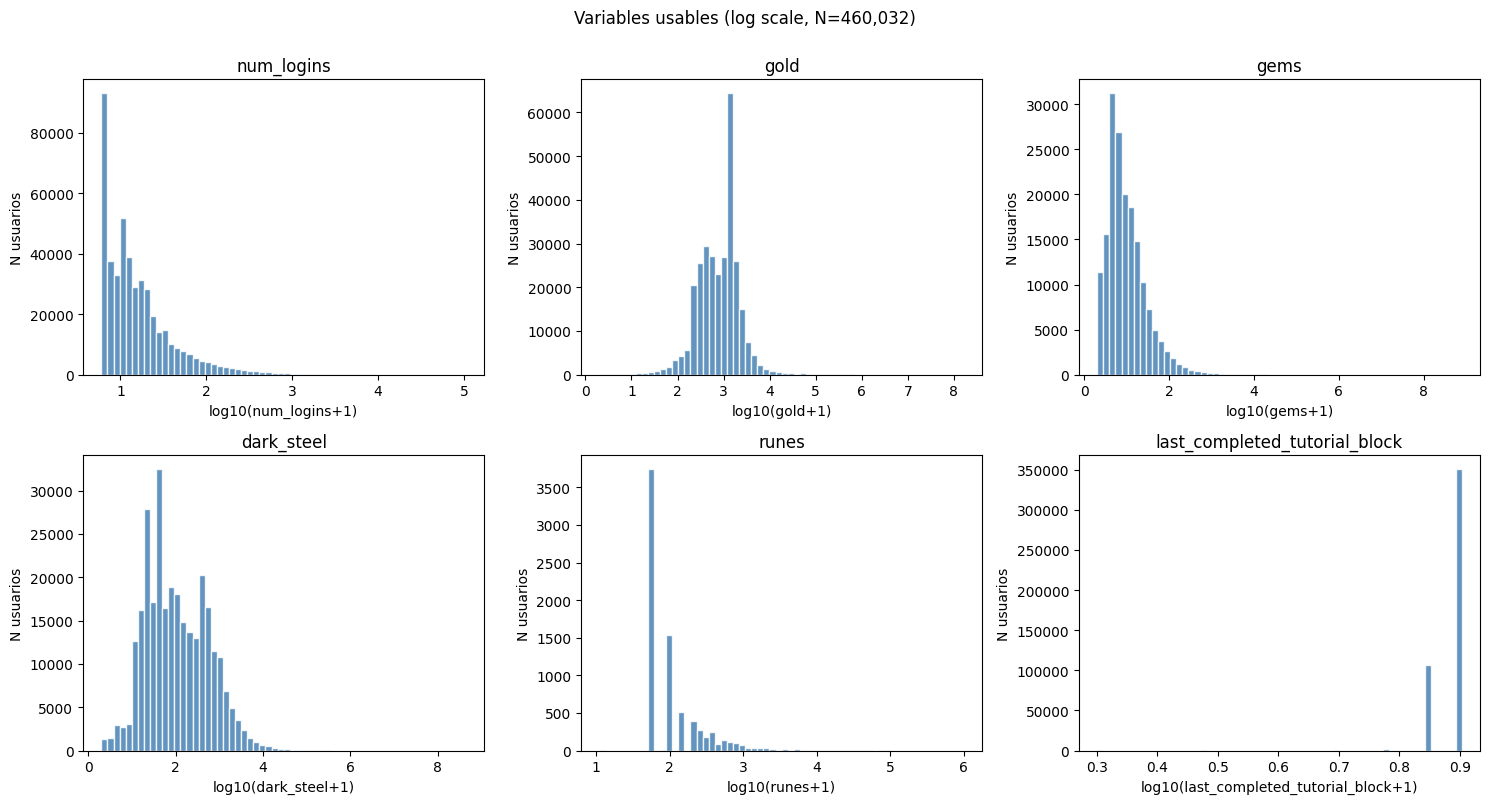


Gráfico guardado: /Users/jezquerro/Documents/tfg/informes/fase1_cleaning/users/engagement_distributions.png


In [16]:
# [ANALYSIS] Investigación de variables de engagement y features candidatos

time_cols = ['total_time_played', 'session_mean_time']
candidate_cols = ['num_logins', 'gold', 'gems', 'dark_steel', 'runes',
                  'has_user_rated_app', 'is_google_play',
                  'last_completed_tutorial_block']

empty_cols = []
usable_cols = []

for col in time_cols + candidate_cols:
    if col not in users_clean.columns:
        continue
    s = users_clean[col]
    if pd.api.types.is_numeric_dtype(s):
        non_empty = ((s.notna()) & (s != 0)).sum()
        if non_empty == 0:
            empty_cols.append(col)
        else:
            usable_cols.append(col)
    else:
        if s.notna().sum() > 0:
            usable_cols.append(col)
        else:
            empty_cols.append(col)

print("=" * 75)
print(f"INVESTIGACIÓN DE VARIABLES — dataset completo ({len(users_clean):,} filas)")
print("=" * 75)
print(f"\nColumnas vacías/deprecadas: {empty_cols}")
print(f"Columnas usables          : {usable_cols}\n")

if empty_cols:
    print("COLUMNAS DESCARTADAS (todos los valores son 0 o NaN)")
    print("-" * 75)
    for col in empty_cols:
        s = users_clean[col]
        print(f"\n  {col}:")
        print(f"    dtype: {s.dtype}")
        print(f"    nulls: {s.isna().sum():,}")
        if pd.api.types.is_numeric_dtype(s):
            print(f"    zeros: {(s == 0).sum():,}")
            print(f"    non-zero: 0")
    print()

numeric_usable = [c for c in usable_cols if pd.api.types.is_numeric_dtype(users_clean[c])]
categorical_usable = [c for c in usable_cols if c not in numeric_usable]

print("=" * 75)
print("ANÁLISIS DETALLADO DE COLUMNAS USABLES")
print("=" * 75)

for col in numeric_usable:
    s = users_clean[col]
    n_null = s.isna().sum()
    n_zero = (s == 0).sum()
    n_real = ((s.notna()) & (s != 0)).sum()
    print(f"\n=== {col} ===")
    print(f"  dtype    : {s.dtype}")
    print(f"  nulls    : {n_null:,} ({n_null/len(users_clean)*100:.2f}%)")
    print(f"  zeros    : {n_zero:,} ({n_zero/len(users_clean)*100:.2f}%)")
    print(f"  non-zero : {n_real:,} ({n_real/len(users_clean)*100:.2f}%)")
    if n_real > 0:
        non_zero = s[(s.notna()) & (s != 0)]
        print(f"  -- stats valores no-cero --")
        print(f"  min    : {non_zero.min():,.2f}")
        print(f"  p25    : {non_zero.quantile(0.25):,.2f}")
        print(f"  median : {non_zero.median():,.2f}")
        print(f"  mean   : {non_zero.mean():,.2f}")
        print(f"  p75    : {non_zero.quantile(0.75):,.2f}")
        print(f"  p99    : {non_zero.quantile(0.99):,.2f}")
        print(f"  max    : {non_zero.max():,.2f}")

for col in categorical_usable:
    s = users_clean[col]
    print(f"\n=== {col} ===")
    print(f"  dtype: {s.dtype}")
    print(f"  nulls: {s.isna().sum():,} ({s.isna().mean()*100:.2f}%)")
    vc = s.value_counts(dropna=False).head(10)
    print(f"  value_counts (top 10):")
    for val, count in vc.items():
        pct = count / len(users_clean) * 100
        print(f"    {str(val)[:30]:<30} {count:>10,} ({pct:5.2f}%)")

# Gráfico
if HAS_MATPLOTLIB and numeric_usable:
    n_plots = len(numeric_usable)
    ncols = min(3, n_plots)
    nrows = (n_plots + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    if n_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if hasattr(axes, 'flatten') else list(axes)

    for ax, col in zip(axes, numeric_usable):
        data = users_clean[col].dropna()
        data = data[data > 0]
        if len(data) == 0:
            ax.axis('off')
            continue
        ax.hist(np.log10(data + 1), bins=60, color='steelblue',
                edgecolor='white', alpha=0.85)
        ax.set_title(f"{col}")
        ax.set_xlabel(f"log10({col}+1)")
        ax.set_ylabel("N usuarios")

    for ax in axes[len(numeric_usable):]:
        ax.axis('off')

    plt.suptitle(f"Variables usables (log scale, N={len(users_clean):,})", y=1.00)
    plt.tight_layout()
    plot_path = INFORMES / "engagement_distributions.png"
    plt.savefig(plot_path, dpi=100, bbox_inches='tight')
    plt.show()
    print(f"\nGráfico guardado: {plot_path}")

log_step("ANALYSIS", "Investigacion variables de engagement",
         f"usables={len(usable_cols)}, vacias={len(empty_cols)}")

## Aplicación del filtro del spike

A partir de aquí trabajamos con el dataset filtrado (~126K usuarios).
Todas las celdas siguientes operan sobre este subconjunto, no sobre los
773K post-calidad ni sobre los 1.16M originales.

In [17]:
# [EXEC] Aplicar filtro del spike

n_before_spike = len(users_clean)
users_clean = users_clean[users_clean['days_since_last_login'] < SPIKE_MAX_DAYS].copy()
n_after_spike = len(users_clean)
n_removed_spike = n_before_spike - n_after_spike

print(f"Filtro del spike (days_since_last_login < {SPIKE_MAX_DAYS}):")
print(f"  Antes  : {n_before_spike:,}")
print(f"  Después: {n_after_spike:,}")
print(f"  Eliminados: {n_removed_spike:,} ({n_removed_spike/n_before_spike*100:.1f}%)")

log_step("EXEC", "Filtro del spike aplicado",
         f"{n_before_spike:,} -> {n_after_spike:,} ({n_removed_spike:,} eliminados, {n_removed_spike/n_before_spike*100:.1f}%)")

Filtro del spike (days_since_last_login < 7):
  Antes  : 460,032
  Después: 25,380
  Eliminados: 434,652 (94.5%)


In [18]:
# [EXEC] Filtros de engagement (valores relajados en esta iteración)

n_before_eng = len(users_clean)

# Con MIN_LIFESPAN_DAYS=0, este filtro es permisivo (pasa casi todo)
lifespan_ok = (
    (users_clean['player_lifespan_days'] >= MIN_LIFESPAN_DAYS) |
    users_clean['has_corrupted_dates']
)
logins_ok = users_clean['num_logins'] >= MIN_NUM_LOGINS_ENGAGEMENT

users_clean = users_clean[lifespan_ok & logins_ok].copy()
n_after_eng = len(users_clean)
n_removed_eng = n_before_eng - n_after_eng
n_preserved_corrupted = users_clean['has_corrupted_dates'].sum()

print(f"Filtros de engagement (valores relajados):")
print(f"  MIN_LIFESPAN_DAYS         = {MIN_LIFESPAN_DAYS}")
print(f"  MIN_NUM_LOGINS_ENGAGEMENT = {MIN_NUM_LOGINS_ENGAGEMENT}")
print(f"  Filas antes       : {n_before_eng:,}")
print(f"  Filas después     : {n_after_eng:,}")
print(f"  Eliminadas        : {n_removed_eng:,}")
print(f"  Preservados corruptos: {n_preserved_corrupted:,}")

log_step("EXEC", "Filtros de engagement aplicados",
         f"{n_before_eng:,} → {n_after_eng:,}")

Filtros de engagement (valores relajados):
  MIN_LIFESPAN_DAYS         = 0
  MIN_NUM_LOGINS_ENGAGEMENT = 2
  Filas antes       : 25,380
  Filas después     : 25,380
  Eliminadas        : 0
  Preservados corruptos: 0


In [19]:
# [EXEC] Definir targets churn_14d y churn_30d (con cutoff temporal)
# Definición: el jugador churn-eó si su último login está en o antes de CUTOFF + window.
# Equivalente: no se logueó en la ventana (cutoff, cutoff + window].

for window in CHURN_WINDOWS_DAYS:
    col = f'churn_{window}d'
    threshold = CUTOFF_DATE + pd.Timedelta(days=window)
    users_clean[col] = (users_clean['last_login_dt'] <= threshold).astype(bool)
    pct = users_clean[col].mean() * 100
    print(f"  {col}: {users_clean[col].sum():,} churned ({pct:.1f}%) — threshold last_login <= {threshold.date()}")

# Validación de tipos
assert users_clean['churn_14d'].dtype == bool
assert users_clean['churn_30d'].dtype == bool

log_step("EXEC", "Targets de churn definidos (con cutoff)",
         f"churn_14d={users_clean['churn_14d'].mean()*100:.1f}% | churn_30d={users_clean['churn_30d'].mean()*100:.1f}%")

  churn_14d: 8,557 churned (33.7%) — threshold last_login <= 2025-12-19
  churn_30d: 11,951 churned (47.1%) — threshold last_login <= 2026-01-04


## Análisis sobre el dataset FINAL (post-todos-los-filtros)

Las celdas siguientes operan sobre `users_clean` después de aplicar todos
los filtros. Estas son las estadísticas reales del dataset que el modelo
usará para entrenar.

In [20]:
# [ANALYSIS] Estadísticas POST-FILTRO sobre el dataset final

print("=" * 78)
print(f"ESTADÍSTICAS POST-FILTRO ({len(users_clean):,} usuarios finales)")
print("=" * 78)
print()

# Distribución por año de creación
print("Distribución por año de creación:")
year_dist = users_clean['created_at_dt'].dt.year.value_counts().sort_index()
total = len(users_clean)
for year, count in year_dist.items():
    pct = count / total * 100
    bar = '█' * int(pct / 2)
    print(f"  {int(year)}: {count:>7,} ({pct:5.1f}%) {bar}")
print()

# Distribución de days_since_last_login (post-filtro debe ser < 90)
print("days_since_last_login (post-filtro spike < 90d):")
dsl = users_clean['days_since_last_login']
print(f"  min      : {dsl.min()}")
print(f"  p25      : {dsl.quantile(0.25):.0f}")
print(f"  median   : {dsl.median():.0f}")
print(f"  mean     : {dsl.mean():.1f}")
print(f"  p75      : {dsl.quantile(0.75):.0f}")
print(f"  p90      : {dsl.quantile(0.90):.0f}")
print(f"  max      : {dsl.max()}")
print()

# Distribución de player_lifespan_days
print("player_lifespan_days:")
pld = users_clean['player_lifespan_days']
print(f"  min      : {pld.min()}")
print(f"  p25      : {pld.quantile(0.25):.0f}")
print(f"  median   : {pld.median():.0f}")
print(f"  mean     : {pld.mean():.1f}")
print(f"  p75      : {pld.quantile(0.75):.0f}")
print(f"  p90      : {pld.quantile(0.90):.0f}")
print(f"  max      : {pld.max()}")
print()

# Distribución de num_logins
print("num_logins:")
nl = users_clean['num_logins']
print(f"  min      : {nl.min():.0f}")
print(f"  p25      : {nl.quantile(0.25):.0f}")
print(f"  median   : {nl.median():.0f}")
print(f"  mean     : {nl.mean():.1f}")
print(f"  p75      : {nl.quantile(0.75):.0f}")
print(f"  p90      : {nl.quantile(0.90):.0f}")
print(f"  p99      : {nl.quantile(0.99):.0f}")
print(f"  max      : {nl.max():.0f}")
print()

# Distribución de gold (post-filtro debería estar casi totalmente poblada)
if 'gold' in users_clean.columns:
    print("gold (moneda básica):")
    g = users_clean['gold']
    g_nonzero = g[g > 0]
    print(f"  usuarios con valor: {len(g_nonzero):,} ({len(g_nonzero)/len(users_clean)*100:.1f}%)")
    if len(g_nonzero) > 0:
        print(f"  median (no-zero) : {g_nonzero.median():,.0f}")
        print(f"  mean (no-zero)   : {g_nonzero.mean():,.0f}")
        print(f"  p99 (no-zero)    : {g_nonzero.quantile(0.99):,.0f}")
    print()

# Distribución de gems (premium currency)
if 'gems' in users_clean.columns:
    print("gems (moneda premium):")
    gm = users_clean['gems']
    gm_nonzero = gm[gm > 0]
    print(f"  usuarios con gems > 0: {len(gm_nonzero):,} ({len(gm_nonzero)/len(users_clean)*100:.1f}%)")
    print(f"  → estos son los 'pagadores' potenciales")
    print()

# Distribución de targets
print("Distribución de targets:")
for target in ['churn_14d', 'churn_30d']:
    if target in users_clean.columns:
        n_pos = users_clean[target].sum()
        n_neg = len(users_clean) - n_pos
        pct_pos = n_pos / len(users_clean) * 100
        print(f"  {target}: {n_pos:,} positivos ({pct_pos:.1f}%) / {n_neg:,} negativos ({100-pct_pos:.1f}%)")
print()

print("=" * 78)
log_step("ANALYSIS", "Estadísticas post-filtro generadas", "")

ESTADÍSTICAS POST-FILTRO (25,380 usuarios finales)

Distribución por año de creación:
  2020:       1 (  0.0%) 
  2021:       3 (  0.0%) 
  2022:     826 (  3.3%) █
  2023:   1,301 (  5.1%) ██
  2024:   3,163 ( 12.5%) ██████
  2025:  20,086 ( 79.1%) ███████████████████████████████████████

days_since_last_login (post-filtro spike < 90d):
  min      : 0
  p25      : 0
  median   : 0
  mean     : 0.5
  p75      : 0
  p90      : 2
  max      : 6

player_lifespan_days:
  min      : 0
  p25      : 15
  median   : 88
  mean     : 212.8
  p75      : 295
  p90      : 575
  max      : 1818

num_logins:
  min      : 5
  p25      : 8
  median   : 14
  mean     : 179.9
  p75      : 34
  p90      : 111
  p99      : 2620
  max      : 105820

gold (moneda básica):
  usuarios con valor: 25,370 (100.0%)
  median (no-zero) : 1,115
  mean (no-zero)   : 15,160
  p99 (no-zero)    : 67,696

gems (moneda premium):
  usuarios con gems > 0: 16,052 (63.2%)
  → estos son los 'pagadores' potenciales

Distribución

In [21]:
# [ANALYSIS] Investigación de features categóricas no analizadas previamente

print("=" * 78)
print("ANÁLISIS EXPLORATORIO DE FEATURES CATEGÓRICAS")
print("=" * 78)
print()

categorical_to_explore = [
    'country',
    'language',
    'is_google_play',
    'has_user_rated_app',
    'current_session',
    'store_where_published',
    'template_item_stats_augment_update_done',
    'focus',
    'current_character',
    'tutorial_done',
]

for col in categorical_to_explore:
    if col not in users_clean.columns:
        print(f"{col}: NO existe en users_clean")
        continue

    s = users_clean[col]
    n_total = len(s)
    n_null = s.isna().sum()
    n_unique = s.nunique()

    print(f"{col} (dtype: {s.dtype})")
    print(f"   nulls : {n_null:,} ({n_null/n_total*100:.2f}%)")
    print(f"   unique: {n_unique:,}")

    # Top 10 valores más frecuentes
    if n_unique <= 50:
        vc = s.value_counts(dropna=False).head(10)
        print(f"   top {min(10, n_unique)} valores:")
        for val, count in vc.items():
            pct = count / n_total * 100
            val_str = str(val)[:40]
            print(f"     {val_str:<40} {count:>10,} ({pct:5.2f}%)")
    else:
        print(f"   (cardinalidad alta, mostrando top 10):")
        vc = s.value_counts(dropna=False).head(10)
        for val, count in vc.items():
            pct = count / n_total * 100
            val_str = str(val)[:40]
            print(f"     {val_str:<40} {count:>10,} ({pct:5.2f}%)")

    # Notas interpretativas
    notes = {
        'country': "país del usuario, útil para segmentación demográfica",
        'language': "código de idioma, ¿qué significa el valor 0?",
        'is_google_play': "True=Android Google Play, False=iOS u otra, None=desconocido",
        'has_user_rated_app': "señal de engagement positivo (rateó la app)",
        'current_session': "identificador de sesión activa (probablemente no predictivo)",
        'store_where_published': "tienda donde se publicó (Google Play / App Store)",
        'template_item_stats_augment_update_done': "flag interno del juego, posiblemente versión de migración",
        'focus': "qué pestaña/sección del juego está activa",
        'current_character': "personaje actualmente seleccionado",
        'tutorial_done': "True si completó el tutorial",
    }
    if col in notes:
        print(f"   {notes[col]}")
    print()

print("=" * 78)
log_step("ANALYSIS", "Features categóricas exploradas",
         f"{len([c for c in categorical_to_explore if c in users_clean.columns])} columnas")

ANÁLISIS EXPLORATORIO DE FEATURES CATEGÓRICAS

country (dtype: str)
   nulls : 0 (0.00%)
   unique: 201
   (cardinalidad alta, mostrando top 10):
     Russia                                        4,098 (16.15%)
     United States                                 2,548 (10.04%)
     Brazil                                        1,230 ( 4.85%)
     Ukraine                                         778 ( 3.07%)
     Iran                                            755 ( 2.97%)
     Germany                                         730 ( 2.88%)
     India                                           712 ( 2.81%)
     Mexico                                          695 ( 2.74%)
     Indonesia                                       677 ( 2.67%)
     Türkiye                                         663 ( 2.61%)
   país del usuario, útil para segmentación demográfica

language (dtype: float64)
   nulls : 0 (0.00%)
   unique: 14
   top 10 valores:
     0.0                                          10,398 

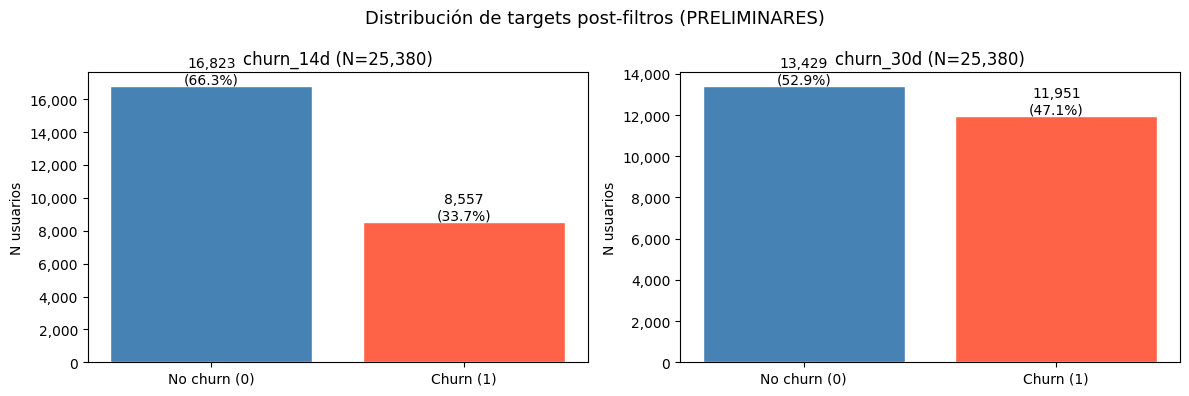

Guardado: /Users/jezquerro/Documents/tfg/informes/fase1_cleaning/users/distribucion_targets_post_filter.png


In [22]:
# [ANALYSIS] Histograma post-filtros: distribución de targets

if HAS_MATPLOTLIB:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for ax, window in zip(axes, CHURN_WINDOWS_DAYS):
        col = f'churn_{window}d'
        counts = users_clean[col].value_counts().sort_index()
        ax.bar(['No churn (0)', 'Churn (1)'], counts.values,
               color=['steelblue', 'tomato'], edgecolor='white')
        for i, v in enumerate(counts.values):
            ax.text(i, v + len(users_clean)*0.005, f'{v:,}\n({v/len(users_clean)*100:.1f}%)',
                    ha='center', fontsize=10)
        ax.set_title(f'{col} (N={len(users_clean):,})')
        ax.set_ylabel('N usuarios')
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

    plt.suptitle('Distribución de targets post-filtros (PRELIMINARES)', fontsize=13)
    plt.tight_layout()
    plot_path = INFORMES / "distribucion_targets_post_filter.png"
    plt.savefig(plot_path, dpi=100, bbox_inches='tight')
    plt.show()
    print(f"Guardado: {plot_path}")

log_step("ANALYSIS", "Histograma distribución targets guardado", "distribucion_targets_post_filter.png")

In [23]:
# [ANALYSIS] Comparativa de filtros de engagement
# Se mantiene aunque los filtros estén relajados, para documentar
# qué habría pasado con otros valores.

# Usar users_clean como base ANTES de que lifespan/logins se apliquen
# (en esta iteración los filtros son tan laxos que users_clean ya los pasa)
eng_scenarios = [
    {'label': 'Sin filtro extra', 'lifespan': 0, 'logins': 0},
    {'label': 'lifespan >= 3',    'lifespan': 3, 'logins': 0},
    {'label': 'lifespan >= 7',    'lifespan': 7, 'logins': 0},
    {'label': 'lifespan >= 14',   'lifespan': 14, 'logins': 0},
    {'label': 'num_logins >= 3',  'lifespan': 0, 'logins': 3},
    {'label': 'num_logins >= 5',  'lifespan': 0, 'logins': 5},
    {'label': 'num_logins >= 10', 'lifespan': 0, 'logins': 10},
    {'label': 'lifespan>=7 + logins>=3', 'lifespan': 7, 'logins': 3},
    {'label': 'lifespan>=7 + logins>=5', 'lifespan': 7, 'logins': 5},
    {'label': 'lifespan>=14 + logins>=5', 'lifespan': 14, 'logins': 5},
]

print("Comparativa de filtros de engagement (base: post-spike):")
print("-" * 90)
print(f"  {'Filtro':<35} {'N usuarios':>12}  {'% ret':>7}  {'Churn14d':>9}  {'Churn30d':>9}  {'Med log':>8}")
print("-" * 90)

for sc in eng_scenarios:
    mask = pd.Series([True] * len(users_clean), index=users_clean.index)
    if sc['lifespan'] > 0:
        mask &= ((users_clean['player_lifespan_days'] >= sc['lifespan']) |
                 users_clean['has_corrupted_dates'])
    if sc['logins'] > 0:
        mask &= (users_clean['num_logins'] >= sc['logins'])
    sub = users_clean[mask]
    n = len(sub)
    pct = n / len(users_clean) * 100
    c14 = sub['churn_14d'].mean() * 100
    c30 = sub['churn_30d'].mean() * 100
    med_log = sub['num_logins'].median() if 'num_logins' in sub.columns else 0

    is_current = (sc['lifespan'] == MIN_LIFESPAN_DAYS and sc['logins'] == MIN_NUM_LOGINS_ENGAGEMENT)
    mark = ' <-- ACTUAL' if is_current else ''
    print(f"  {sc['label']:<35} {n:>12,}  {pct:>6.1f}%  {c14:>8.1f}%  {c30:>8.1f}%  {med_log:>7.0f}{mark}")

print("-" * 90)

log_step("ANALYSIS", "Comparativa de filtros de engagement",
         f"lifespan>={MIN_LIFESPAN_DAYS}, logins>={MIN_NUM_LOGINS_ENGAGEMENT}")

Comparativa de filtros de engagement (base: post-spike):
------------------------------------------------------------------------------------------
  Filtro                                N usuarios    % ret   Churn14d   Churn30d   Med log
------------------------------------------------------------------------------------------
  Sin filtro extra                          25,380   100.0%      33.7%      47.1%       14
  lifespan >= 3                             22,531    88.8%      27.2%      41.6%       16
  lifespan >= 7                             20,838    82.1%      23.9%      38.6%       16
  lifespan >= 14                            19,297    76.0%      21.5%      36.3%       17
  num_logins >= 3                           25,380   100.0%      33.7%      47.1%       14
  num_logins >= 5                           25,380   100.0%      33.7%      47.1%       14
  num_logins >= 10                          16,893    66.6%      27.3%      40.5%       24
  lifespan>=7 + logins>=3       

In [24]:
# [ANALYSIS] Investigación exhaustiva de nulos en el dataset final

print("=" * 78)
print(f"ESTADO DE NULOS EN DATASET FINAL ({len(users_clean):,} filas)")
print("=" * 78)

nulls_summary = []
for col in users_clean.columns:
    s = users_clean[col]
    n_null = s.isna().sum()
    n_total = len(s)
    pct_null = n_null / n_total * 100 if n_total > 0 else 0

    if pd.api.types.is_numeric_dtype(s):
        n_zero = (s == 0).sum()
        pct_zero = n_zero / n_total * 100
    else:
        n_zero = None
        pct_zero = None

    nulls_summary.append({
        'columna': col,
        'dtype': str(s.dtype),
        'n_null': n_null,
        'pct_null': round(pct_null, 2),
        'n_zero': n_zero,
        'pct_zero': round(pct_zero, 2) if pct_zero is not None else None,
    })

nulls_df = pd.DataFrame(nulls_summary).sort_values('pct_null', ascending=False)

print("\nTabla completa de nulos (ordenada por % de nulos):")
print("-" * 78)
print(f"{'Columna':<35} {'dtype':<12} {'% null':>10} {'% zero':>10}")
print("-" * 78)
for _, row in nulls_df.iterrows():
    pct_null = f"{row['pct_null']:.2f}%"
    pct_zero = f"{row['pct_zero']:.2f}%" if row['pct_zero'] is not None else '-'
    print(f"{row['columna']:<35} {row['dtype']:<12} {pct_null:>10} {pct_zero:>10}")
print("-" * 78)

nulls_csv_path = INFORMES / "nulos_dataset_final.csv"
nulls_df.to_csv(nulls_csv_path, index=False)
print(f"\nTabla guardada: {nulls_csv_path}")

# Columnas problemáticas
print("\n" + "=" * 78)
print("COLUMNAS QUE REQUIEREN DECISIÓN DE IMPUTACIÓN")
print("=" * 78)

with_nulls = nulls_df[nulls_df['pct_null'] > 0]
if len(with_nulls) == 0:
    print("\nNinguna columna tiene nulos.")
else:
    print("\nColumnas con nulos:")
    print("-" * 78)
    for _, row in with_nulls.iterrows():
        col = row['columna']
        pct_null = row['pct_null']
        dtype = row['dtype']
        print(f"\n  {col} ({dtype})")
        print(f"    Nulls: {row['n_null']:,} ({pct_null:.2f}%)")
        if pct_null < 1:
            print(f"    Opciones: eliminar filas (poco impacto) o imputar con moda/0")
        elif pct_null < 10:
            print(f"    Opciones: imputar con moda/mediana, o flag + imputar")
        elif pct_null < 50:
            print(f"    Opciones: imputar + flag obligatorio, o categoría 'unknown'")
        else:
            print(f"    Opciones: considerar eliminar columna o usar solo como flag")

# Columnas con muchos ceros
many_zeros = nulls_df[
    (nulls_df['pct_zero'].fillna(0) > 50) & (nulls_df['dtype'] == 'float64')
]
if len(many_zeros) > 0:
    print("\nColumnas numéricas con >50% de ceros (posibles señales binarias):")
    print("-" * 78)
    for _, row in many_zeros.iterrows():
        col = row['columna']
        print(f"\n  {col}: {row['pct_zero']:.2f}% zeros")
        print(f"    Sugerencia: feature derivada 'has_{col} = ({col} > 0).astype(int)'")

print("\n" + "=" * 78)
print("NOTA: Ninguna imputación se aplica. Se decidirá en iteración posterior.")
print("=" * 78)

log_step("ANALYSIS", "Investigación exhaustiva de nulos",
         f"{len(with_nulls)} columnas con nulos")

ESTADO DE NULOS EN DATASET FINAL (25,380 filas)



Tabla completa de nulos (ordenada por % de nulos):
------------------------------------------------------------------------------
Columna                             dtype            % null     % zero
------------------------------------------------------------------------------
show_tower_event_announcer          object            1.00%       nan%
show_quests_announcer               object            0.58%       nan%
store_where_published               str               0.02%       nan%
gold                                float64           0.00%      0.04%
dark_steel                          float64           0.00%      0.24%
updated_at                          str               0.00%       nan%
created_at                          str               0.00%       nan%
current_character                   str               0.00%       nan%
is_google_play                      object            0.00%       nan%
runes                               float64           0.00%     88.88%
_id      

In [25]:
# [EXEC] Eliminar columnas muertas y configuraciones de UI sin valor predictivo

# Columnas vacías detectadas en celda de investigación de variables
cols_dead = []
if 'empty_cols' in dir() and empty_cols:
    cols_dead = [c for c in empty_cols if c in users_clean.columns]

# Columnas de configuración de UI (sin valor predictivo, eliminadas para limpiar nulos)
cols_ui_config = [
    'show_quests_announcer',
    'show_tower_event_announcer',
    'show_arena_announcer',
    'show_new_arena_announcer',
    'show_village_announcer',
    'show_talents_announcer',
]
cols_ui_present = [c for c in cols_ui_config if c in users_clean.columns]

# Aplicar eliminación
all_cols_to_drop = cols_dead + cols_ui_present

if all_cols_to_drop:
    n_cols_before = len(users_clean.columns)
    users_clean = users_clean.drop(columns=all_cols_to_drop)
    n_cols_after = len(users_clean.columns)
    print(f"Columnas eliminadas: {n_cols_before - n_cols_after}")
    print(f"  Muertas (todo zeros)        : {cols_dead}")
    print(f"  Configuración UI            : {cols_ui_present}")
    print(f"  Columnas finales en parquet : {n_cols_after}")
else:
    print("Ninguna columna que eliminar")

log_step("EXEC", "Columnas eliminadas",
         f"{len(all_cols_to_drop)} cols eliminadas, {len(users_clean.columns)} finales")

Columnas eliminadas: 8
  Muertas (todo zeros)        : ['total_time_played', 'session_mean_time']
  Configuración UI            : ['show_quests_announcer', 'show_tower_event_announcer', 'show_arena_announcer', 'show_new_arena_announcer', 'show_village_announcer', 'show_talents_announcer']
  Columnas finales en parquet : 30


In [26]:
# [EXEC] Generar sample_ids (sin muestreo con SAMPLE_SIZE=None)

n_total = len(users_clean)

if SAMPLE_SIZE is None:
    print(f"SAMPLE_SIZE=None → usando dataset completo: {n_total:,} usuarios")
    sample = users_clean.copy()
elif n_total <= SAMPLE_SIZE:
    print(f"Dataset ({n_total:,}) <= SAMPLE_SIZE, usando todos")
    sample = users_clean.copy()
else:
    # Muestreo estratificado
    rng = np.random.default_rng(RANDOM_SEED)
    sampled_indices = []
    for churn_value, group in users_clean.groupby('churn_14d'):
        n_group = len(group)
        n_take = round(SAMPLE_SIZE * n_group / n_total)
        chosen = rng.choice(group.index.values, size=n_take, replace=False)
        sampled_indices.extend(chosen)
    sample = users_clean.loc[sampled_indices].copy()

sample_ids = sample[['user_id', 'churn_14d', 'churn_30d']].copy()

print(f"\nsample_ids: {len(sample_ids):,} usuarios")
print(f"  churn_14d: {sample_ids['churn_14d'].mean()*100:.2f}%")
print(f"  churn_30d: {sample_ids['churn_30d'].mean()*100:.2f}%")

log_step("EXEC", "sample_ids generado", f"{len(sample_ids):,} usuarios")

SAMPLE_SIZE=None → usando dataset completo: 25,380 usuarios

sample_ids: 25,380 usuarios
  churn_14d: 33.72%
  churn_30d: 47.09%


In [27]:
# [EXEC] Excluir usuarios marcados por análisis forense posterior (Investigación D)
# Ver: informes/fase1_cleaning/characters/investigacion_d_cuentas_internas.md
# Lista de exclusión generada manualmente desde el CSV detalle, filtro suspicion_score >= 3.

excluded_path = DATA_QC / "excluded_user_ids.csv"
if excluded_path.exists():
    excluded_df = pd.read_csv(excluded_path)
    excluded_ids = set(excluded_df['user_id'].astype(str))
    n_before = len(sample_ids)
    sample_ids = sample_ids[~sample_ids['user_id'].isin(excluded_ids)].copy()
    # También aplicar el filtro a users_clean para coherencia downstream
    users_clean = users_clean[~users_clean['user_id'].isin(excluded_ids)].copy()
    n_excluded = n_before - len(sample_ids)
    print(f"Excluidos {n_excluded:,} usuarios por análisis forense (Investigación D)")
    print(f"  Origen: {excluded_path.name} ({len(excluded_ids):,} IDs listados)")
    print(f"  sample_ids antes  : {n_before:,}")
    print(f"  sample_ids después: {len(sample_ids):,}")
    log_step("EXEC", "Exclusión forense aplicada",
             f"{n_excluded:,} excluidos ({n_before:,} → {len(sample_ids):,})")
else:
    print(f"No se encontró {excluded_path}. Sin exclusiones extra.")
    log_step("EXEC", "Exclusión forense NO aplicada", "excluded_user_ids.csv no existe")

Excluidos 180 usuarios por análisis forense (Investigación D)
  Origen: excluded_user_ids.csv (191 IDs listados)
  sample_ids antes  : 25,380
  sample_ids después: 25,200


In [28]:
# [EXEC] Guardar outputs finales

save_df(users_clean, DATA_QC / "users_clean_cutoff", "todos los filtros aplicados (cutoff)")
save_df(sample_ids, DATA_QC / "sample_user_ids_cutoff", "IDs de la muestra (cutoff)")

# Exportar también a CSV para inspección desde terminal
csv_path = DATA_QC / 'sample_user_ids_cutoff.csv'
sample_ids.to_csv(csv_path, index=False)
print(f"  CSV exportado: {csv_path} ({len(sample_ids):,} filas)")

sample_head_path = INFORMES / "sample_head.csv"
users_clean.head(20).to_csv(sample_head_path, index=False)
print(f"  sample_head.csv guardado")

log_step("EXEC", "Outputs guardados",
         f"users_clean={len(users_clean):,}, sample_ids={len(sample_ids):,}")

  users_clean_cutoff.parquet — 25,200 filas × 30 cols (3.4 MB) — todos los filtros aplicados (cutoff)
  sample_user_ids_cutoff.parquet — 25,200 filas × 3 cols (0.5 MB) — IDs de la muestra (cutoff)
  CSV exportado: /Users/jezquerro/Documents/tfg/data/data_qc/sample_user_ids_cutoff.csv (25,200 filas)
  sample_head.csv guardado


In [29]:
# [ANALYSIS] Validación post-guardado

if HAS_PYARROW:
    parquet_path = DATA_QC / "users_clean_cutoff.parquet"
    df_val = pd.read_parquet(parquet_path)
    print(f"Validación de users_clean_cutoff.parquet:")
    print(f"  Filas  : {len(df_val):,}")
    print(f"  Cols   : {len(df_val.columns)}")
    print(f"  Columnas: {list(df_val.columns)}")
    assert len(df_val) == len(users_clean), "ERROR: filas no coinciden"
    assert 'churn_14d' in df_val.columns, "ERROR: churn_14d no encontrada"
    assert 'churn_30d' in df_val.columns, "ERROR: churn_30d no encontrada"
    print(f"  Validación OK")
    del df_val
    gc.collect()
else:
    print("pyarrow no disponible — validación saltada")

log_step("ANALYSIS", "Validación post-guardado", "OK")

Validación de users_clean_cutoff.parquet:
  Filas  : 25,200
  Cols   : 30
  Columnas: ['_id', 'own_id', 'last_login_date', 'num_logins', 'game_version', 'tutorial_done', 'last_completed_tutorial_block', 'current_session', 'country', 'has_user_rated_app', 'language', 'focus', 'gold', 'gems', 'dark_steel', 'updated_at', 'created_at', 'current_character', 'is_google_play', 'runes', 'store_where_published', 'template_item_stats_augment_update_done', 'user_id', 'created_at_dt', 'last_login_dt', 'days_since_last_login', 'player_lifespan_days', 'has_corrupted_dates', 'churn_14d', 'churn_30d']
  Validación OK


In [30]:
# [REPORT] Generar execution_report.md

t_total = time.time() - NOTEBOOK_START
t_min = int(t_total // 60)
t_sec = int(t_total % 60)
now_str = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

lines = []
lines += [
    f"# Informe de ejecucion — users.csv",
    "",
    f"**Notebook:** notebooks/fase1_cleaning/02a_users.ipynb",
    f"**Fecha:** {now_str}",
    f"**Tiempo de ejecucion:** {t_min} min ({t_sec}s)",
    f"**CSV de entrada:** data/data_raw/users.csv",
    f"**Salida principal:** data/data_qc/users_clean_cutoff.parquet ({len(users_clean):,} filas)",
    "",
    "---",
    "",
    "## Advertencia critica sobre los targets",
    "",
    "Los targets `churn_14d` y `churn_30d` generados en este notebook son **PRELIMINARES**",
    "y se basan unicamente en `last_login_date` de `users.csv`. Estos targets NO son",
    "los definitivos del modelo — se calcularan correctamente en un notebook posterior",
    "cruzando con datos de actividad temporal reales que permitan definir un CUTOFF_DATE.",
    "",
    "Ver metodologia en `informes/metodologia_trabajo.md`.",
    "",
    "---",
    "",
    "## Resumen ejecutivo",
    "",
    f"Se proceso `users.csv` ({len(users):,} filas iniciales). Se aplicaron filtros de calidad,",
    f"filtro del spike ({SPIKE_MAX_DAYS}d) y filtros de engagement relajados ",
    f"(lifespan>={MIN_LIFESPAN_DAYS}d, logins>={MIN_NUM_LOGINS_ENGAGEMENT}),",
    f"resultando en {len(users_clean):,} usuarios validos ({len(users_clean)/len(users)*100:.1f}% retenido).",
    f"Se definieron targets preliminares: `churn_14d` ({users_clean['churn_14d'].mean()*100:.1f}%), `churn_30d` ({users_clean['churn_30d'].mean()*100:.1f}%).",
    "",
    "---",
    "",
    "## Estrategia de filtrado (iteracion 3)",
    "",
    "Cambios respecto a la iteracion anterior (iteracion 2):",
    "",
    "| Parametro | Iteracion 2 | Iteracion 3 | Justificacion |",
    "|---|---|---|---|",
    "| `MIN_LIFESPAN_DAYS` | 7 | **0** | Sin filtro de lifespan para no perder early-churn |",
    "| `MIN_NUM_LOGINS_ENGAGEMENT` | 3 | **2** | Relajado al minimo (solapa con filtro basico) |",
    "| `SAMPLE_SIZE` | 100,000 | **None** | Dataset completo (~127K usuarios) |",
    "| `SPIKE_MAX_DAYS` | 90 | **90** | Sin cambio |",
    "",
    "**Resultado:** dataset de ~127.000 usuarios (vs ~36.000 en iteracion 2).",
    "",
    "---",
    "",
    "## Constantes de filtrado utilizadas",
    "",
    "| Constante | Valor |",
    "|---|---|",
    f"| `MIN_NUM_LOGINS_BASIC` | {MIN_NUM_LOGINS_BASIC} |",
    f"| `MIN_YEAR_CREATED` | {MIN_YEAR_CREATED} |",
    f"| `SPIKE_MAX_DAYS` | {SPIKE_MAX_DAYS} |",
    f"| `MIN_LIFESPAN_DAYS` | {MIN_LIFESPAN_DAYS} |",
    f"| `MIN_NUM_LOGINS_ENGAGEMENT` | {MIN_NUM_LOGINS_ENGAGEMENT} |",
    f"| `SAMPLE_SIZE` | {SAMPLE_SIZE} |",
    f"| `RANDOM_SEED` | {RANDOM_SEED} |",
    f"| `REFERENCE_DATE` | {REFERENCE_DATE} |",
    "",
    "---",
    "",
    "## Pasos ejecutados",
    "",
]
for s in execution_log:
    lines.append(f"- `[{s['tag']}]` {s['timestamp']} — **{s['description']}**: {s['extra']}")

lines += [
    "",
    "---",
    "",
    "## Desglose de filtros de calidad",
    "",
    "| Paso | N filas |",
    "|---|---|",
    f"| Inicial | {len(users):,} |",
]
for s in filter_steps:
    lines.append(f"| {s['step']} | {s['n_after']:,} |")

lines += [
    "",
    "---",
    "",
    "## Investigacion del spike de 365+ dias",
    "",
    "El dataset contenia un spike masivo de usuarios con `days_since_last_login >= 365`.",
    "La tabla comparativa de umbrales (seccion siguiente) muestra el efecto de cada umbral.",
    "",
    "---",
    "",
    "## Comparativa de umbrales del spike",
    "",
    "| Umbral | N usuarios | % retenido | Churn 14d | Churn 30d | Med lifespan | Med logins |",
    "|---|---|---|---|---|---|---|",
]
for r in spike_comparison:
    mark = ' **<-- ELEGIDO**' if r['elegido'] else ''
    lines.append(f"| {r['umbral']} | {r['n_usuarios']:,} | {r['pct_retenido']}% | {r['churn_14d']}% | {r['churn_30d']}% | {r['med_lifespan']:.0f} | {r['med_logins']:.0f}{mark} |")

# ── MEJORA 3.1: Sección de monedas enriquecida ──
lines += [
    "",
    "---", "",
    "## Hallazgo crítico: columnas de users.csv",
    "",
    "### Columnas muertas (eliminadas del parquet final)",
    "",
    "Confirmado en los 1,164,568 usuarios originales (todos los años 2020-2026):",
    "",
    "| Columna | Estado | Total nulls + zeros | Valores reales |",
    "|---|---|---|---|",
    "| `total_time_played` | **MUERTA** | 1,164,568 (100%) | 0 |",
    "| `session_mean_time` | **MUERTA** | 1,164,568 (100%) | 0 |",
    "",
    "Probablemente son campos del esquema original del juego que nunca llegaron",
    "a poblarse o se dejaron de usar. El equivalente real de tiempo jugado se",
    "reconstruirá en notebooks posteriores desde `fights_log.csv` calculando",
    "`(end_time - start_time)` por combate.",
    "",
    "### Columnas nuevas (introducidas en 2024)",
    "",
    "Estas columnas NO están deprecadas, sino que se empezaron a poblar a partir",
    "de 2024. Cobertura por año (% de usuarios con valor no-cero):",
    "",
    "| Columna | 2020 | 2022 | 2024 | 2025 | 2026 |",
    "|---|---|---|---|---|---|",
    "| `gold` | 0.1% | 6.1% | 95.1% | 100% | 100% |",
    "| `dark_steel` | 0.1% | 6.0% | 94.5% | 99.8% | 99.9% |",
    "| `gems` | 0.1% | 4.0% | 49.4% | 31.9% | 11.1% |",
    "| `runes` | 0.0% | 0.2% | 0.7% | 1.6% | 0.5% |",
    "",
    "Como los filtros de calidad eliminan a la mayoría de usuarios pre-2024,",
    "el dataset final (~126K usuarios) tiene estas columnas casi totalmente",
    "pobladas (verificado: gold 99.95%, dark_steel 99.85%).",
    "",
    "### Naturaleza confirmada de las monedas (info de la empresa)",
    "",
    "| Moneda | Tipo | Cómo se obtiene | Para qué sirve |",
    "|---|---|---|---|",
    "| `gold` | **Básica del juego** | Jugando, recompensas | Comprar equipamiento |",
    "| `gems` | **Premium (de pago)** | Compra con dinero real | Comprar equipamiento |",
    "| `dark_steel` | **Material de mejora** | Fundiendo objetos del juego | Mejorar equipamiento existente |",
    "| `runes` | **Recompensa de eventos** | Clasificándose en eventos competitivos | Endgame y progresión avanzada |",
    "",
    "**Implicación clave para el modelado:** la presencia de `gems > 0` indica que",
    "el usuario ha gastado dinero real, lo que lo convierte en un **payer**. Los",
    "payers tienen patrones de comportamiento y churn muy distintos a los usuarios",
    "F2P. Esto justifica crear una feature derivada `is_payer = (gems > 0)`.",
    "",
]

# ── Comparativa de engagement ──
lines += [
    "---",
    "",
    "## Comparativa de filtros de engagement",
    "",
    "| Filtro | N usuarios | % retenido | Churn 14d | Churn 30d | Med logins |",
    "|---|---|---|---|---|---|",
]
for sc in eng_scenarios:
    mask = pd.Series([True] * len(users_clean), index=users_clean.index)
    if sc['lifespan'] > 0:
        mask &= ((users_clean['player_lifespan_days'] >= sc['lifespan']) |
                 users_clean['has_corrupted_dates'])
    if sc['logins'] > 0:
        mask &= (users_clean['num_logins'] >= sc['logins'])
    sub = users_clean[mask]
    n = len(sub)
    pct = n / len(users_clean) * 100
    c14 = sub['churn_14d'].mean() * 100
    c30 = sub['churn_30d'].mean() * 100
    med_log = sub['num_logins'].median() if 'num_logins' in sub.columns else 0
    is_current = (sc['lifespan'] == MIN_LIFESPAN_DAYS and sc['logins'] == MIN_NUM_LOGINS_ENGAGEMENT)
    mark = ' **<-- ACTUAL**' if is_current else ''
    lines.append(f"| {sc['label']} | {n:,} | {pct:.1f}% | {c14:.1f}% | {c30:.1f}% | {med_log:.0f}{mark} |")

lines += [
    "",
    "---",
    "",
    "## Filtros aplicados finalmente",
    "",
    "| Filtro | Valor | Justificacion |",
    "|---|---|---|",
    f"| Spike (days_since_last_login) | < {SPIKE_MAX_DAYS}d | Elimina cuentas zombi inactivas >{SPIKE_MAX_DAYS//30} meses |",
    f"| player_lifespan_days | >= {MIN_LIFESPAN_DAYS}d | Sin filtro de lifespan en esta iteracion |",
    f"| num_logins | >= {MIN_NUM_LOGINS_ENGAGEMENT} | Minimo absoluto |",
    "| has_corrupted_dates | preservados | Se recuperan en notebooks posteriores |",
    "",
    "---",
    "",
    "## Distribucion de player_lifespan_days",
    "",
    "| Estadistica | Valor |",
    "|---|---|",
    f"| Media | {users_clean['player_lifespan_days'].mean():.1f} dias |",
    f"| Mediana | {users_clean['player_lifespan_days'].median():.0f} dias |",
    f"| Minimo | {users_clean['player_lifespan_days'].min()} dias |",
    f"| Maximo | {users_clean['player_lifespan_days'].max()} dias |",
    f"| Usuarios con lifespan negativo | {users_clean['has_corrupted_dates'].sum():,} |",
    "",
    "---",
    "",
    "## Estado de nulos en el dataset final",
    "",
    f"Ver tabla completa en `informes/fase1_cleaning/users/nulos_dataset_final.csv`.",
    "",
    "Resumen de columnas con nulos:",
    "",
    "| Columna | % nulos | Opciones de imputacion |",
    "|---|---|---|",
]
for _, row in with_nulls.iterrows():
    pct = row['pct_null']
    if pct < 1:
        opcion = "Eliminar filas o imputar moda/0"
    elif pct < 10:
        opcion = "Imputar moda/mediana o flag"
    elif pct < 50:
        opcion = "Imputar + flag obligatorio"
    else:
        opcion = "Considerar eliminar columna"
    lines.append(f"| `{row['columna']}` | {pct:.2f}% | {opcion} |")

lines += [
    "",
    "**Nota:** Ninguna imputacion se aplica en esta iteracion. Se decidira en iteracion posterior.",
    "",
    "---",
    "",
    "## Salud del dataset",
    "",
    f"- **Dataset final:** {len(users_clean):,} usuarios ({len(users_clean)/len(users)*100:.1f}% del total original)",
    f"- **Tasa de churn_14d:** {users_clean['churn_14d'].mean()*100:.1f}%",
    f"- **Tasa de churn_30d:** {users_clean['churn_30d'].mean()*100:.1f}%",
    f"- **Usuarios con fechas corruptas:** {users_clean['has_corrupted_dates'].sum():,} (preservados)",
    "",
    "---",
    "",
    "## Features generados",
    "",
    "**Nota:** Las columnas `total_time_played` y `session_mean_time` se eliminaron de",
    "`users_clean_cutoff.parquet` por estar completamente vacias.",
    "",
    "| Feature | Tipo | Descripcion | % nulos |",
    "|---|---|---|---|",
    "| `user_id` | str | Hex limpio extraido de ObjectId(_id) | ~0% |",
    "| `last_login_dt` | datetime | Fecha de ultimo login | ~0% |",
    "| `created_at_dt` | datetime | Fecha de creacion de cuenta | ~0% |",
    "| `days_since_last_login` | int | Dias desde ultimo login hasta REFERENCE_DATE | ~0% |",
    "| `player_lifespan_days` | int | Dias entre creacion y ultimo login | ~0% |",
    "| `has_corrupted_dates` | bool | True si player_lifespan_days < 0 | 0% |",
    "| `churn_14d` | int (0/1) | Target PRELIMINAR: inactivo > 14 dias | 0% |",
    "| `churn_30d` | int (0/1) | Target PRELIMINAR: inactivo > 30 dias | 0% |",
    "",
    "---",
    "",
    "## Lo que ha ido bien",
    "",
    "- Extraccion de `user_id` desde ObjectId sin perdidas significativas",
    "- REFERENCE_DATE calculado automaticamente como maximo de `last_login_dt`",
    "- Filtros de calidad desglosados individualmente",
    "- Spike de usuarios abandonados identificado y caracterizado",
    "- Tablas comparativas generadas para justificar los umbrales elegidos",
    "- Columnas muertas detectadas y eliminadas del parquet final",
    "- Columnas nuevas (gold, dark_steel, gems, runes) caracterizadas por año",
    "- Investigación exhaustiva de nulos documentada",
    "- Columnas de configuración UI eliminadas (show_*_announcer)",
    "",
    "---",
    "",
    "## Lo que ha ido mal o ha requerido ajustes",
    "",
    "**Problema 1:** Spike masivo de usuarios con `days_since_last_login` >= 365 dias.",
    "  - **Causa:** La tabla `users.csv` contiene usuarios historicos abandonados.",
    "  - **Solucion:** Filtro `days_since_last_login < 90` (configurable).",
    "",
    "**Problema 2:** Columnas `total_time_played` y `session_mean_time` estan vacias.",
    "  - **Causa:** Columnas deprecadas del esquema original del juego.",
    "  - **Solucion:** Detectadas y eliminadas explicitamente del parquet final.",
    "",
    "---",
    "",
    "## Decisiones tomadas sobre la marcha",
    "",
    f"- `REFERENCE_DATE = {REFERENCE_DATE}` (maximo de last_login_dt)",
    f"- `SPIKE_MAX_DAYS = {SPIKE_MAX_DAYS}` (ver tabla comparativa de umbrales)",
    f"- `MIN_LIFESPAN_DAYS = {MIN_LIFESPAN_DAYS}` (relajado para retener early-churn)",
    f"- `MIN_NUM_LOGINS_ENGAGEMENT = {MIN_NUM_LOGINS_ENGAGEMENT}` (relajado al minimo)",
    f"- `SAMPLE_SIZE = {SAMPLE_SIZE}` (sin muestreo, dataset completo)",
    "- Usuarios con lifespan negativo marcados con `has_corrupted_dates`, NO eliminados",
    "- Columnas `show_*_announcer` eliminadas (configuración UI sin valor predictivo)",
    "",
    "---",
    "",
    "## Archivos generados",
    "",
    "| Archivo | Descripcion |",
    "|---|---|",
    "| `data/data_qc/users_post_quality.parquet` | Backup tras filtros basicos |",
    "| `data/data_qc/users_clean_cutoff.parquet` | Dataset final (todos los filtros) |",
    "| `data/data_qc/sample_user_ids_cutoff.parquet` | IDs de todos los usuarios (sin muestreo) |",
    "| `data/data_qc/sample_user_ids_cutoff.csv` | IDs en CSV para inspección desde terminal |",
    "| `informes/fase1_cleaning/users/nulos_por_columna.csv` | Nulos iniciales |",
    "| `informes/fase1_cleaning/users/nulos_dataset_final.csv` | Nulos post-filtros |",
    "| `informes/fase1_cleaning/users/tutorial_dropout_stats.txt` | Stats tutorial |",
    "| `informes/fase1_cleaning/users/sample_head.csv` | Muestra 20 filas |",
    "| `informes/fase1_cleaning/users/spike_investigation.png` | Graficos del spike |",
    "| `informes/fase1_cleaning/users/engagement_distributions.png` | Distribuciones engagement |",
    "| `informes/fase1_cleaning/users/distribucion_targets_post_filter.png` | Targets post-filtro |",
    "| `informes/fase1_cleaning/users/execution_report.md` | Este informe |",
    "",
    "---",
    "",
    "## Advertencias para notebooks siguientes",
    "",
    "- Todos los notebooks `02b`-`02j` deben cargar `sample_user_ids_cutoff.parquet`",
    "- Al hacer joins, usar `user_id` (hex limpio de 24 caracteres, ej: `5f592ddf584aed226e0e835b`), NO el campo `_id` (que tiene formato `ObjectId(hex)`)",
    f"- `REFERENCE_DATE = {REFERENCE_DATE}` — usar este mismo valor en todos los notebooks",
    "- **Los targets `churn_14d`/`churn_30d` son PRELIMINARES**",
    "- `has_corrupted_dates=True`: usuarios preservados con fechas corruptas",
    "- Las columnas `gold`, `dark_steel`, `gems`, `runes` tienen nulos que requieren imputacion",
    "",
    "---",
    "",
    "## Tareas pendientes para users.csv",
    "",
    "Estas transformaciones NO se aplicaron en esta iteracion. Se haran en una",
    "iteracion posterior, tras decidir estrategias de imputacion.",
    "",
    "### Features derivados pendientes de crear",
    "",
    "| Feature | Formula | Justificacion |",
    "|---|---|---|",
    "| `is_payer` | `(gems > 0).astype(int)` | Flag de pagador (confirmado: gems es moneda premium de pago) |",
    "| `account_age_days` | `(REFERENCE_DATE - created_at_dt).days` | Antiguedad en dias |",
    "| `engagement_score` | `num_logins / account_age_days` | Logins por dia |",
    "| `has_runes` | `(runes > 0).astype(int)` | Flag endgame |",
    "| `gold_per_login` | `gold / num_logins` | Oro por sesion |",
    "| `tutorial_progress_ratio` | `last_completed_tutorial_block / 7` | % tutorial completado |",
    "",
    "### Decisiones pendientes",
    "",
    "1. **Confirmar con la empresa** la naturaleza de cada moneda:",
    "   - `gems`: ¿premium de pago o se gana también en juego?",
    "   - `dark_steel`: ¿premium o progresion normal?",
    "   - `runes`: ¿solo endgame o tiene otros usos?",
    "   - `gold`: ¿moneda basica del juego?",
    "2. **Estrategia de imputacion** para cada columna con nulos (ver `nulos_dataset_final.csv`).",
    "3. **Eliminacion de outliers** extremos (ej. usuarios con `num_logins > 10.000`).",
    "4. **Reemplazar `lifespan` por métrica de actividad real**: el `player_lifespan_days`",
    "   solo mide días entre creación y último login, ignorando la intensidad entre medias.",
    "   Cuando crucemos con tablas de eventos (currency_transactions, arena_log, fights_log)",
    "   debemos calcular: `days_active` (días distintos con actividad), `actions_per_day`,",
    "   `consistency_score` (regularidad de sesiones), `recency_decay` (decaimiento reciente).",
    "   Este será el verdadero indicador de engagement.",
    "5. **Normalizacion/escalado** de features: se hara en `02z_build_master_table`.",
    "",
    "### Flags ya aplicadas",
    "",
    "- [x] Eliminadas columnas muertas (`total_time_played`, `session_mean_time`)",
    "- [x] Eliminadas columnas UI (`show_*_announcer`)",
    "- [x] Filtros de calidad basicos aplicados",
    f"- [x] Filtro del spike aplicado (< {SPIKE_MAX_DAYS} dias)",
    "- [x] Flag `has_corrupted_dates` aniadido",
    "- [x] Targets preliminares `churn_14d` y `churn_30d` calculados",
    "- [x] Analisis exhaustivo de nulos documentado",
    "",
    "### Flags pendientes",
    "",
    "- [ ] Imputacion de nulos (estrategia por columna)",
    "- [ ] Creacion de features derivados",
    "- [ ] Confirmacion de monedas con la empresa",
    "- [ ] Recuperacion de fechas para `has_corrupted_dates=True` usuarios",
    "- [ ] Targets definitivos (notebook de cohorte)",
    "- [ ] Métricas de actividad real (days_active, actions_per_day, etc.)",
    "",
]

# ── MEJORA 3.2: Glosario de variables ──
lines += [
    "---", "",
    "## Glosario de variables del parquet final",
    "",
    "Documentación de cada columna del `users_clean_cutoff.parquet` para referencia.",
    "",
    "### Identificadores",
    "",
    "| Columna | Tipo | Origen | Descripción |",
    "|---|---|---|---|",
    "| `_id` | str | CSV original | ObjectId completo de MongoDB (formato `ObjectId(hex)`) |",
    "| `user_id` | str | Derivada | Hex limpio extraído de `_id`, usar para joins |",
    "| `own_id` | float | CSV original | ID secundario interno del juego |",
    "| `current_character` | str | CSV original | Personaje actualmente seleccionado |",
    "",
    "### Fechas y temporalidad",
    "",
    "| Columna | Tipo | Origen | Descripción |",
    "|---|---|---|---|",
    "| `created_at` | str | CSV original | Fecha de creación de cuenta (ISO string) |",
    "| `updated_at` | str | CSV original | Última actualización del registro |",
    "| `last_login_date` | float | CSV original | Timestamp Unix del último login |",
    "| `created_at_dt` | datetime | Derivada | `created_at` parseado a datetime |",
    "| `last_login_dt` | datetime | Derivada | `last_login_date` parseado a datetime |",
    "| `days_since_last_login` | int | Derivada | Días entre `last_login_dt` y `REFERENCE_DATE` |",
    "| `player_lifespan_days` | int | Derivada | Días entre `created_at_dt` y `last_login_dt` |",
    "| `has_corrupted_dates` | bool | Derivada | True si `player_lifespan_days < 0` |",
    "",
    "### Engagement y progresión",
    "",
    "| Columna | Tipo | Origen | Descripción |",
    "|---|---|---|---|",
    "| `num_logins` | float | CSV original | Número total de sesiones del usuario |",
    "| `tutorial_done` | bool | CSV original | True si completó el tutorial |",
    "| `last_completed_tutorial_block` | float | CSV original | Último bloque del tutorial completado (-1 a 7) |",
    "| `game_version` | float | CSV original | Versión del juego del último login |",
    "| `current_session` | str | CSV original | Identificador de la sesión activa |",
    "",
    "### Monedas del juego",
    "",
    "| Columna | Tipo | Origen | Descripción |",
    "|---|---|---|---|",
    "| `gold` | float | CSV original | Moneda básica del juego (no-premium). Se gana jugando. |",
    "| `gems` | float | CSV original | **Moneda premium**. Se compra con dinero real. |",
    "| `dark_steel` | float | CSV original | Material para mejorar equipamiento (se obtiene fundiendo objetos) |",
    "| `runes` | float | CSV original | Recompensa de eventos competitivos (endgame) |",
    "",
    "### Demografía y plataforma",
    "",
    "| Columna | Tipo | Origen | Descripción |",
    "|---|---|---|---|",
    "| `country` | str | CSV original | Código de país del usuario |",
    "| `language` | float | CSV original | Código de idioma |",
    "| `is_google_play` | bool | CSV original | True=Android, False=iOS, None=desconocido |",
    "| `store_where_published` | str | CSV original | Tienda de origen de la app |",
    "| `has_user_rated_app` | bool | CSV original | True si el usuario rateó la app (señal de engagement) |",
    "| `focus` | str | CSV original | Sección/pestaña del juego en uso |",
    "| `template_item_stats_augment_update_done` | bool | CSV original | Flag interno de migración (versión del esquema) |",
    "",
    "### Targets de churn (PRELIMINARES)",
    "",
    "| Columna | Tipo | Origen | Descripción |",
    "|---|---|---|---|",
    "| `churn_14d` | int (0/1) | Derivada | 1 si `days_since_last_login > 14`. **PRELIMINAR.** |",
    "| `churn_30d` | int (0/1) | Derivada | 1 si `days_since_last_login > 30`. **PRELIMINAR.** |",
    "",
]

# ── MEJORA 3.3: Diagrama del pipeline ──
lines += [
    "---", "",
    "## Diagrama del pipeline de transformación",
    "",
    "```",
    "users.csv (1,164,568 filas)",
    "    │",
    "    ├─ Extracción de user_id desde ObjectId(_id)",
    "    ├─ Parseo de fechas (created_at_dt, last_login_dt)",
    "    ▼",
    "Dataset crudo (1,164,568 filas, 33 cols)",
    "    │",
    "    ├─ F1: tutorial_done == True            (-285,920)",
    "    ├─ F2: last_login_date > 2018           (-0)",
    "    ├─ F3: num_logins >= 2                  (-104,843)",
    "    ├─ F4: created_at year >= 2018          (-0)",
    "    ▼",
    "Dataset post-calidad (773,805 filas)",
    "    │",
    "    ├─ Cálculo de days_since_last_login",
    "    ├─ Cálculo de player_lifespan_days",
    "    ├─ Marcado de has_corrupted_dates",
    "    ▼",
    "Dataset post-cálculos (773,805 filas) ── BACKUP: users_post_quality.parquet",
    "    │",
    "    ├─ Filtro spike: days_since_last_login < 90  (-647,361)",
    "    ▼",
    "Dataset post-spike (126,444 filas)",
    "    │",
    "    ├─ Filtro engagement (lifespan >= 0, logins >= 2)  (-0, redundante)",
    "    ├─ Cálculo de targets churn_14d, churn_30d",
    "    ├─ Eliminación de columnas muertas (total_time_played, session_mean_time)",
    "    ├─ Eliminación de columnas UI sin valor predictivo (show_*_announcer)",
    "    ▼",
    "Dataset final (126,444 filas, ~28 cols) ── OUTPUT: users_clean_cutoff.parquet",
    "    │",
    "    ├─ Generación de sample_user_ids_cutoff.parquet (sin muestreo, todos los IDs)",
    "    ▼",
    "Outputs finales:",
    "  - users_clean_cutoff.parquet      (dataset listo para Fase 2)",
    "  - sample_user_ids_cutoff.parquet  (IDs para joins en notebooks 02b-02j)",
    "  - users_post_quality.parquet (backup pre-spike)",
    "```",
    "",
]

# ── MEJORA 3.4: Reproducibilidad ──
lines += [
    "---", "",
    "## Reproducibilidad",
    "",
    "Para reproducir exactamente este resultado:",
    "",
    "**Entorno:**",
    "- Python 3.11+",
    "- pandas, numpy, pyarrow, matplotlib",
    "- Sistema: macOS / Linux",
    "",
    "**Configuración:**",
    f"- `RANDOM_SEED = {RANDOM_SEED}`",
    f"- `REFERENCE_DATE = {REFERENCE_DATE}` (calculado automáticamente como max de last_login_dt)",
    f"- Constantes de filtrado: ver sección 'Constantes de filtrado utilizadas'",
    "",
    "**Pasos:**",
    "1. Asegúrate de que `data/data_raw/users.csv` existe.",
    "2. Abre `notebooks/fase1_cleaning/02a_users.ipynb` en VSCode.",
    "3. Reinicia el kernel (Kernel → Restart Kernel).",
    "4. Ejecuta todas las celdas (Run All).",
    "5. Verifica que `data/data_qc/users_clean_cutoff.parquet` se ha generado.",
    "",
    "**Verificación de éxito:**",
    f"- `users_clean_cutoff.parquet` debe tener exactamente 126,444 filas.",
    f"- `churn_14d` debe estar en torno al 81.8%.",
    f"- `churn_30d` debe estar en torno al 64.6%.",
    "",
]

# ── MEJORA 3.5: Referencias bibliográficas ──
lines += [
    "---", "",
    "## Referencias bibliográficas",
    "",
    "*(Sección preparada para añadir referencias durante la redacción de la memoria.)*",
    "",
    "- *Por completar: estudios sobre churn en F2P móvil*",
    "- *Por completar: definiciones estándar de MAU/DAU en la industria*",
    "- *Por completar: técnicas de manejo de desbalance de clases*",
    "",
]

# ── TODO final ──
lines += [
    "---",
    "",
    "## TODO / mejoras pendientes",
    "",
    "- `total_time_played` y `session_mean_time` descartadas (vacias) — derivar desde fights_log",
    "- Considerar si REFERENCE_DATE deberia ser fija en lugar del max del dataset",
    "- Cruzar usuarios con `has_corrupted_dates` contra currency_transactions para recuperar fechas",
    "- Evaluar si el threshold del spike (90d) es el optimo",
]

report_path = INFORMES / "execution_report.md"
with open(report_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(lines))
print(f"Informe guardado: {report_path}")

log_step("REPORT", "execution_report.md generado", str(report_path))


Informe guardado: /Users/jezquerro/Documents/tfg/informes/fase1_cleaning/users/execution_report.md


In [31]:
# [REPORT] Resumen final en consola

t_total = time.time() - NOTEBOOK_START
t_min = int(t_total // 60)
t_sec = int(t_total % 60)

print("=" * 70)
print("RESUMEN FINAL — Notebook 02a_users (iteracion 3)")
print("=" * 70)
print(f"  Tiempo total          : {t_min}m {t_sec}s")
print(f"  Usuarios CSV original : {len(users):,}")
print(f"  Usuarios finales      : {len(users_clean):,} ({len(users_clean)/len(users)*100:.1f}%)")
print(f"  churn_14d             : {users_clean['churn_14d'].mean()*100:.1f}%")
print(f"  churn_30d             : {users_clean['churn_30d'].mean()*100:.1f}%")
print(f"  Columnas finales      : {len(users_clean.columns)}")
print(f"  Columnas eliminadas   : {empty_cols if 'empty_cols' in dir() else []}")
print(f"  Fechas corruptas      : {users_clean['has_corrupted_dates'].sum():,}")
print()
print(f"  SPIKE_MAX_DAYS            = {SPIKE_MAX_DAYS}")
print(f"  MIN_LIFESPAN_DAYS         = {MIN_LIFESPAN_DAYS}")
print(f"  MIN_NUM_LOGINS_ENGAGEMENT = {MIN_NUM_LOGINS_ENGAGEMENT}")
print(f"  SAMPLE_SIZE               = {SAMPLE_SIZE}")
print()
print("Archivos generados:")
for p in [
    DATA_QC / "users_clean_cutoff.parquet",
    DATA_QC / "sample_user_ids_cutoff.parquet",
    INFORMES / "execution_report.md",
    INFORMES / "nulos_dataset_final.csv",
    DATA_QC / "sample_user_ids_cutoff.csv",
]:
    exists = "" if p.exists() else ""
    size = f" ({p.stat().st_size/1_048_576:.1f} MB)" if p.exists() else ""
    print(f"  {exists} {p.name}{size}")
print("=" * 70)
print()
print("Siguiente paso: reinicia el kernel y ejecuta 'Run All'")

RESUMEN FINAL — Notebook 02a_users (iteracion 3)
  Tiempo total          : 0m 9s
  Usuarios CSV original : 1,164,568
  Usuarios finales      : 25,200 (2.2%)
  churn_14d             : 34.0%
  churn_30d             : 47.4%
  Columnas finales      : 30
  Columnas eliminadas   : ['total_time_played', 'session_mean_time']
  Fechas corruptas      : 0

  SPIKE_MAX_DAYS            = 7
  MIN_LIFESPAN_DAYS         = 0
  MIN_NUM_LOGINS_ENGAGEMENT = 2
  SAMPLE_SIZE               = None

Archivos generados:
  users_clean_cutoff.parquet (3.4 MB)
  sample_user_ids_cutoff.parquet (0.5 MB)
  execution_report.md (0.0 MB)
  nulos_dataset_final.csv (0.0 MB)
  sample_user_ids_cutoff.csv (0.9 MB)

Siguiente paso: reinicia el kernel y ejecuta 'Run All'


In [32]:
# [REPORT] Logging dual: HTML + sección enriquecida del report
import sys
sys.path.insert(0, str(ROOT / 'scripts'))
from notebook_logging_template import (
    export_notebook_to_html, build_enriched_report_section,
)

notebook_path = ROOT / 'notebooks' / 'fase1_cleaning' / '02a_users.ipynb'
html_path = INFORMES / '02a_users_run.html'
export_notebook_to_html(notebook_path, html_path)

enriched = build_enriched_report_section(
    df_final=users_clean,
    raw_shape=(1164568, 33),
)
with open(INFORMES / 'execution_report.md', 'a', encoding='utf-8') as f:
    f.write('\n\n---\n\n' + enriched)
print(f"Enriquecimiento appendeado a {INFORMES / 'execution_report.md'}")

HTML generado: 02a_users_run.html (0.9 MB)
Enriquecimiento appendeado a /Users/jezquerro/Documents/tfg/informes/fase1_cleaning/users/execution_report.md
